<a href="https://colab.research.google.com/github/JEMALkedir/Cement/blob/main/Eku_FIXED_journal_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CELL 1 — Install Required Packages

# 📌 CRITICAL — Read this BEFORE inserting figures into MS Word

This notebook now exports **journal-ready figures** in the correct **physical size** so they fit Word columns at **100 %** with **no resizing → no quality loss**.

## ✅ How figures are now exported
| File | Purpose | Use this when… |
|------|---------|----------------|
| `*.tiff` (LZW, 600 DPI) | Final submission to journal | Most journals ask for TIFF |
| `*.png`  (600 DPI) | Insert into Word manuscript | Best for Word — no compression artefacts |
| `*.pdf`  (vector) | Reviewer / archival | Never loses quality at any zoom |
| `*.svg`  (vector) | Editing in Illustrator / Inkscape | Final tweaks |

## 🛑 The #1 reason images look bad in Word — FIX IT NOW
Word **automatically compresses images** when you save the document. This **destroys** your 600-DPI figures. **Turn it OFF before pasting any figure**:

**Word → File → Options → Advanced → Image Size and Quality**
1. ✅ Tick **"Do not compress images in file"**
2. Set **"Default resolution"** to **High fidelity** (or 330 ppi)
3. Click **OK**

(On Mac: *Word → Preferences → Edit → Picture Compression*.)

## 📐 Figure sizes used here (journal standard)
- **Single-column** figure: **3.5 in (89 mm)** wide
- **Double-column** figure: **7.0 in (180 mm)** wide
- Aspect ratios chosen to match column heights — **no shrinking needed in Word**

## 📥 How to insert figures correctly into Word
1. In Word: **Insert → Pictures → This Device** → choose the `*.png` file
2. **Do NOT drag and drop** — that pastes a low-res preview
3. **Do NOT copy-paste from Colab preview** — Colab shows a low-DPI version
4. After inserting, **do not resize** with the corner handles (already correct size)
5. Save as `.docx` (after toggling off compression — see above)

## 🖨️ For final journal submission
- Submit the **`.tiff`** files directly (most journals require TIFF)
- Or submit the **`.pdf`** vector versions (preferred by many journals)

---


In [1]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")
print(response)

The capital of France is **Paris**.


In [2]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sun Apr 26 08:36:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   35C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import psutil

ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 56.9 gigabytes of available RAM

You are using a high-RAM runtime!


In [4]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 1: Install Required Packages                                   ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("📦 CELL 1: Installing required packages...")

import subprocess, sys
subprocess.run(
    [sys.executable, '-m', 'pip', 'install',
     'xgboost', 'lightgbm', 'catboost', 'optuna', 'shap', 'openpyxl', '-q'],
    capture_output=True
)
print("✅ All packages installed successfully!")


📦 CELL 1: Installing required packages...
✅ All packages installed successfully!


 CELL 2 — Load Data and Define Target

In [5]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 2: Load Data and Define Target                                 ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("📂 CELL 2: Loading dataset from Google Drive...")

import pandas as pd
from google.colab import drive

# 1. Mount the drive
drive.mount('/content/drive')

# 2. Load dataset
df_raw = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Strength/Strength_EBH2.xlsx')
TARGET = 'Strength_Mpa'

print("✅ Dataset loaded successfully!")
print(f"✅ Dataset shape   : {df_raw.shape}")
print(f"✅ Target variable : {TARGET}")


📂 CELL 2: Loading dataset from Google Drive...
Mounted at /content/drive
✅ Dataset loaded successfully!
✅ Dataset shape   : (304, 19)
✅ Target variable : Strength_Mpa


CELL 3 — Import Libraries and Set Publication Environment (1200 DPI)

In [48]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 3: Imports + Journal-Quality Figure Configuration              ║
# ║  (600 DPI, journal column widths, multi-format export)               ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("📚 CELL 3: Loading libraries and journal figure environment...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

SEED = 42
np.random.seed(SEED)

# ───────────────────────────────────────────────────────────────────────
#  JOURNAL-QUALITY FIGURE SETTINGS
# ───────────────────────────────────────────────────────────────────────
PUB_DPI     = 600       # 600 DPI = journal standard (sharper than 1200 in Word!)
DISPLAY_DPI = 110       # screen preview DPI (keeps Colab responsive)

# Standard journal column widths (in inches)
COL_SINGLE = 3.5        # ~89 mm  — single-column figures
COL_DOUBLE = 7.0        # ~180 mm — double-column figures
COL_1_5    = 5.0        # ~127 mm — 1.5-column figures

# Output folder
FIG_DIR = 'figures_journal'
os.makedirs(FIG_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', context='paper')   # 'paper' = small print fonts

plt.rcParams.update({
    # Resolution
    'figure.dpi'        : DISPLAY_DPI,
    'savefig.dpi'       : PUB_DPI,
    'savefig.bbox'      : 'tight',
    'savefig.pad_inches': 0.02,
    'savefig.facecolor' : 'white',
    'figure.facecolor'  : 'white',
    # Fonts — sized for ACTUAL print size (3.5" / 7.0")
    'font.family'       : 'serif',
    'font.serif'        : ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size'         : 8,
    'axes.titlesize'    : 9,
    'axes.labelsize'    : 8,
    'xtick.labelsize'   : 7,
    'ytick.labelsize'   : 7,
    'legend.fontsize'   : 7,
    'figure.titlesize'  : 10,
    # Axes
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'grid.linewidth'    : 0.4,
    'axes.linewidth'    : 0.8,
    'xtick.major.width' : 0.6,
    'ytick.major.width' : 0.6,
    'lines.linewidth'   : 1.2,
    'lines.markersize'  : 4,
    # PDF / SVG keep text editable in Illustrator
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
    'svg.fonttype'      : 'none',
})

# ───────────────────────────────────────────────────────────────────────
#  save_pub(name) — saves PNG + TIFF (LZW) + PDF + SVG
#  All formats embed correct DPI so Word reads the right physical size.
# ───────────────────────────────────────────────────────────────────────
def save_pub(name, fig=None, dpi=PUB_DPI, formats=('png', 'tiff', 'pdf', 'svg'), pil_kwargs=None):
    """Save current figure (or `fig`) in multiple journal-ready formats."""
    if fig is None:
        fig = plt.gcf()
    base = os.path.join(FIG_DIR, name)

    if 'png' in formats:
        final_pil_kwargs_png = {'optimize': True}
        if pil_kwargs:
            final_pil_kwargs_png.update(pil_kwargs)
        fig.savefig(f'{base}.png',  dpi=dpi, bbox_inches='tight',
                    facecolor='white', pil_kwargs=final_pil_kwargs_png)
    if 'tiff' in formats:
        # LZW compression + embedded DPI metadata (so Word reads the size correctly)
        final_pil_kwargs_tiff = {'compression': 'tiff_lzw', 'dpi': (dpi, dpi)}
        if pil_kwargs:
            final_pil_kwargs_tiff.update(pil_kwargs)
        fig.savefig(f'{base}.tiff', dpi=dpi, bbox_inches='tight',
                    facecolor='white',
                    pil_kwargs=final_pil_kwargs_tiff)
    if 'pdf' in formats:
        fig.savefig(f'{base}.pdf',  bbox_inches='tight', facecolor='white')
    if 'svg' in formats:
        fig.savefig(f'{base}.svg',  bbox_inches='tight', facecolor='white')

    print(f"   ✅ Saved {FIG_DIR}/{name}.{{{','.join(formats)}}}  @ {dpi} DPI")

print(f"✅ Environment ready. Figures will be saved to ./{FIG_DIR}/  at {PUB_DPI} DPI")
print(f"   • Single-column width = {COL_SINGLE} ({COL_SINGLE*25.4:.0f} mm)")
print(f"   • Double-column width = {COL_DOUBLE} ({COL_DOUBLE*25.4:.0f} mm)")

📚 CELL 3: Loading libraries and journal figure environment...
✅ Environment ready. Figures will be saved to ./figures_journal/  at 600 DPI
   • Single-column width = 3.5 (89 mm)
   • Double-column width = 7.0 (178 mm)


CELL 4 — Check Missing Values

In [7]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 4: Check Missing Values                                        ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("🔎 CELL 4: Checking missing values...")

missing_values_count = df_raw.isnull().sum()
print(missing_values_count)
print(f"\n✅ Total missing values: {missing_values_count.sum()}")


🔎 CELL 4: Checking missing values...
WB_ratio                 0
OPC                      0
CSC                      0
Fly_Ash                  0
Slag                     0
BRC                      0
Limestone                0
Glass_Powder             0
Metakaolin               0
Wollastonite             0
Gypsum                   0
Quartz                   0
NaHCO3                   0
Carbonation_Time_days    0
Age_days                 0
RH                       0
Temp_C                   0
CO2                      0
Strength_Mpa             0
dtype: int64

✅ Total missing values: 0


CELL 5 — Statistical Evaluation Summary

In [8]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 5: Statistical Evaluation Summary (All Features)               ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("📊 CELL 5: Computing statistical summary of all numeric features...")

import pandas as pd
from scipy.stats import skew, kurtosis

# 1. Select only numerical columns (includes OPC, Fly Ash, Target, etc.)
numeric_df = df_raw.select_dtypes(include=['number'])

# 2. Calculate all statistics for all columns at once
stats_summary = numeric_df.agg([
    'max',
    'min',
    'mean',
    'median',
    'std',
    'var',
    lambda x: skew(x.dropna()),
    lambda x: kurtosis(x.dropna())
]).T  # Transpose to put Features as the vertical index

# 3. Rename columns to your specific notation
stats_summary.columns = [
    'Max.', 'Min.', 'm (Mean)', 'med (Median)',
    's (Std Dev)', 's² (Variance)', 'sk (Skewness)', 'k (Kurtosis)'
]

# 4. Display the results
print("\n--- Statistical Evaluation Summary (All Features) ---")
print(stats_summary.round(4))

# 5. Save to Excel for the paper (publication-ready)
stats_summary.round(4).to_excel('Statistical_Summary.xlsx')
print("\n✅ Saved: Statistical_Summary.xlsx")


📊 CELL 5: Computing statistical summary of all numeric features...

--- Statistical Evaluation Summary (All Features) ---
                         Max.   Min.  m (Mean)  med (Median)  s (Std Dev)  \
WB_ratio                 0.50   0.18    0.3485         0.335       0.1046   
OPC                    100.00   0.00   61.0294        66.670      34.9794   
CSC                    100.00   0.00   11.3471         0.000      19.9178   
Fly_Ash                 30.00   0.00    4.0664         0.000       7.7122   
Slag                   100.00   0.00   14.5116         0.000      29.8622   
BRC                    100.00   0.00    2.5658         0.000      14.8033   
Limestone               20.00   0.00    0.3947         0.000       2.4727   
Glass_Powder            30.00   0.00    0.1974         0.000       2.1404   
Metakaolin              30.00   0.00    2.5263         0.000       7.2165   
Wollastonite            15.00   0.00    1.0263         0.000       3.2293   
Gypsum                  33.33  

CELL 6 — Correlation Matrix Heatmap (1200 DPI)

🌡️ CELL 6: Generating correlation matrix heatmap...
   ✅ Saved figures_journal/Fig_Correlation_Matrix.{png,tiff,pdf,svg}  @ 600 DPI


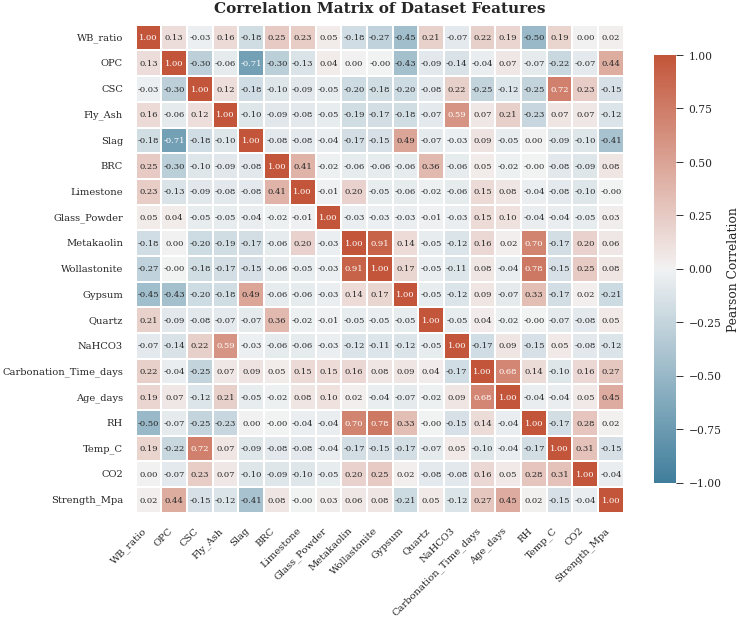


--- Correlation with Strength_Mpa ---
Strength_Mpa             1.000000
Age_days                 0.447971
OPC                      0.439947
Carbonation_Time_days    0.266763
Wollastonite             0.082225
BRC                      0.076383
Metakaolin               0.063156
Quartz                   0.053659
Glass_Powder             0.026584
WB_ratio                 0.019756
RH                       0.015469
Limestone               -0.003688
CO2                     -0.044173
NaHCO3                  -0.124210
Fly_Ash                 -0.124219
CSC                     -0.149302
Temp_C                  -0.154924
Gypsum                  -0.209070
Slag                    -0.412905
Name: Strength_Mpa, dtype: float64


In [9]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 6: Correlation Matrix Heatmap — Journal Quality (double col)   ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("🌡️ CELL 6: Generating correlation matrix heatmap...")

corr_matrix = numeric_df.corr()

# Double-column figure — square, fits 180 mm width
fig, ax = plt.subplots(figsize=(COL_DOUBLE, COL_DOUBLE * 0.92))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_matrix,
    cmap=cmap, vmax=1.0, vmin=-1.0, center=0,
    annot=True, fmt=".2f",
    annot_kws={'size': 5.5},
    square=True,
    linewidths=.3, linecolor='white',
    cbar_kws={"shrink": .7, "label": "Pearson Correlation"},
    ax=ax
)
ax.set_title('Correlation Matrix of Dataset Features',
             fontsize=10, fontweight='bold', pad=8)
plt.xticks(rotation=45, ha='right', fontsize=6.5)
plt.yticks(rotation=0, fontsize=6.5)
plt.tight_layout()

save_pub('Fig_Correlation_Matrix')
plt.show()

if TARGET in corr_matrix.columns:
    print(f"\n--- Correlation with {TARGET} ---")
    print(corr_matrix[TARGET].sort_values(ascending=False))


CELL 7 — Distribution of All Features (1200 DPI, Pastel Style)

📊 CELL 7: Plotting distribution of all features (pastel style)...
   ✅ Saved figures_journal/Fig_Distributions_Pastel.{png,tiff,pdf,svg}  @ 600 DPI


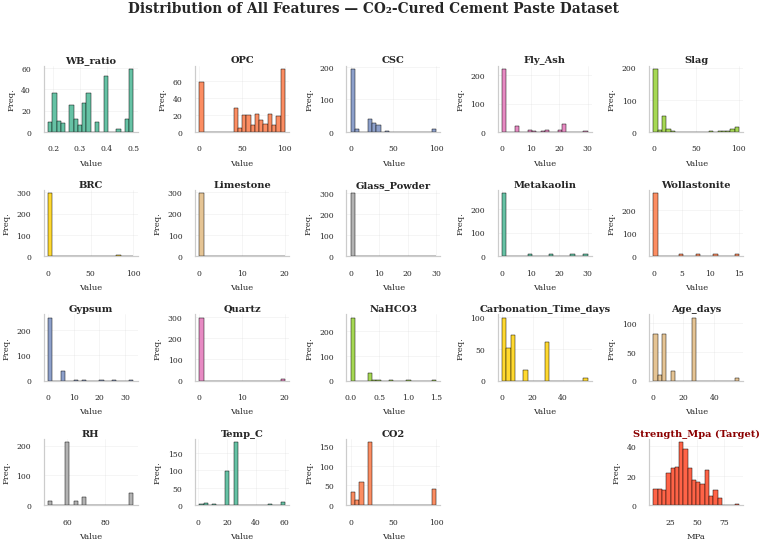

In [10]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 7: Distribution of All Features — Pastel — Journal Quality     ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("📊 CELL 7: Plotting distribution of all features (pastel style)...")

features = [
    'WB_ratio', 'OPC', 'CSC', 'Fly_Ash', 'Slag',
    'BRC', 'Limestone', 'Glass_Powder', 'Metakaolin',
    'Wollastonite', 'Gypsum', 'Quartz',
    'NaHCO3', 'Carbonation_Time_days', 'Age_days',
    'RH', 'Temp_C', 'CO2'
]

# 4×5 grid double-column figure
fig, axes = plt.subplots(4, 5, figsize=(COL_DOUBLE, COL_DOUBLE * 0.72))
axes = axes.flatten()

colors = plt.cm.Set2.colors

for i, col in enumerate(features):
    axes[i].hist(df_raw[col], bins=20,
                 color=colors[i % len(colors)],
                 edgecolor='black', linewidth=0.3)
    axes[i].set_title(col, fontweight='bold', pad=2, fontsize=6.5)
    axes[i].set_xlabel('Value', fontsize=5.5)
    axes[i].set_ylabel('Freq.', fontsize=5.5)
    axes[i].tick_params(axis='both', labelsize=5)
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

if len(features) < 19:
    axes[18].axis('off')

axes[19].hist(df_raw[TARGET], bins=20,
              color='tomato', edgecolor='black', linewidth=0.3)
axes[19].set_title(f'{TARGET} (Target)', fontweight='bold',
                   color='darkred', pad=2, fontsize=6.5)
axes[19].set_xlabel('MPa', fontsize=5.5)
axes[19].set_ylabel('Freq.', fontsize=5.5)
axes[19].tick_params(axis='both', labelsize=5)
axes[19].grid(axis='y', alpha=0.3)
axes[19].spines['top'].set_visible(False)
axes[19].spines['right'].set_visible(False)

plt.suptitle('Distribution of All Features — CO₂-Cured Cement Paste Dataset',
             fontsize=9, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])

save_pub('Fig_Distributions_Pastel')
plt.show()


CELL 8 — Distribution with KDE Overlay (1200 DPI, Graphical-Abstract Style)

📊 CELL 8: Plotting feature distributions with KDE overlay...
   ✅ Saved figures_journal/Fig_Feature_Distribution_KDE.{png,tiff,pdf,svg}  @ 600 DPI


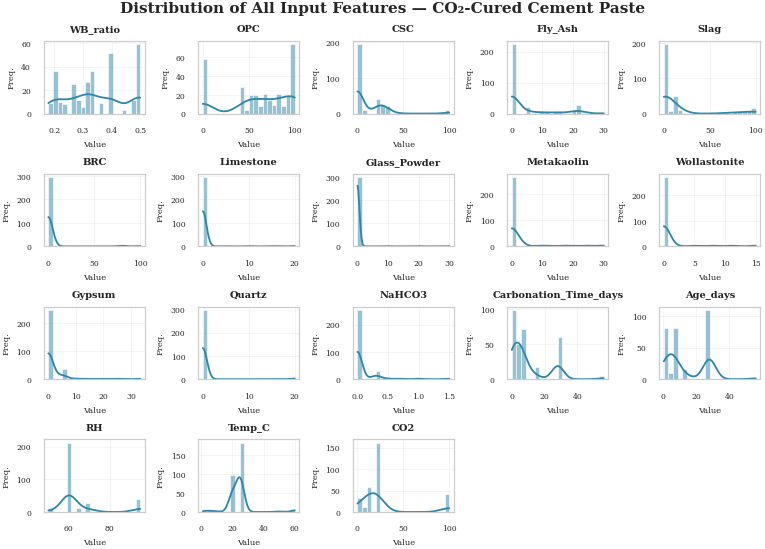

In [11]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 8: Feature Distribution with KDE Overlay — Journal Quality    ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("📊 CELL 8: Plotting feature distributions with KDE overlay...")

features = [
    'WB_ratio', 'OPC', 'CSC', 'Fly_Ash', 'Slag',
    'BRC', 'Limestone', 'Glass_Powder', 'Metakaolin',
    'Wollastonite', 'Gypsum', 'Quartz',
    'NaHCO3', 'Carbonation_Time_days', 'Age_days',
    'RH', 'Temp_C', 'CO2'
]

fig, axes = plt.subplots(4, 5, figsize=(COL_DOUBLE, COL_DOUBLE * 0.72),
                         constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df_raw[col], bins=20, kde=True, ax=axes[i],
                 color='#2E86AB', edgecolor='white', linewidth=0.4)
    axes[i].set_title(col, fontsize=6.5, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=5.5)
    axes[i].set_ylabel('Freq.', fontsize=5.5)
    axes[i].tick_params(axis='both', labelsize=5)

for j in range(len(features), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribution of All Input Features — CO₂-Cured Cement Paste',
             fontsize=10, fontweight='bold')

save_pub('Fig_Feature_Distribution_KDE')
plt.show()


CELL 9 — Main Feature Selection and Cleaning


In [12]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 9: Main Feature Selection and Cleaning                        ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("🧹 CELL 9: Selecting only the original input features and cleaning them...")

ORIGINAL_FEATURES = [
    'WB_ratio',
    'OPC',
    'CSC',
    'Fly_Ash',
    'Slag',
    'BRC',
    'Limestone',
    'Glass_Powder',
    'Metakaolin',
    'Wollastonite',
    'Gypsum',
    'Quartz',
    'NaHCO3',
    'Carbonation_Time_days',
    'Age_days',
    'RH',
    'Temp_C',
    'CO2'
]

missing_features = [c for c in ORIGINAL_FEATURES if c not in df_raw.columns]
if missing_features:
    raise ValueError(f"Missing required original features in dataset: {missing_features}")

df_eng = df_raw[ORIGINAL_FEATURES + [TARGET]].copy()

# Clean inf/nan using only the original features
df_eng[ORIGINAL_FEATURES] = df_eng[ORIGINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
df_eng[ORIGINAL_FEATURES] = df_eng[ORIGINAL_FEATURES].fillna(df_eng[ORIGINAL_FEATURES].median())

ALL_FEATS = ORIGINAL_FEATURES.copy()

print("✅ Main-feature dataset prepared successfully.")
print(f"✅ Original input features used : {len(ALL_FEATS)}")
print(f"✅ Engineered features added    : 0")
print(f"✅ Final modeling features      : {len(ALL_FEATS)}")
print("✅ SHAP and all downstream analyses will use only the original variables.")


🧹 CELL 9: Selecting only the original input features and cleaning them...
✅ Main-feature dataset prepared successfully.
✅ Original input features used : 18
✅ Engineered features added    : 0
✅ Final modeling features      : 18
✅ SHAP and all downstream analyses will use only the original variables.


CELL 10 — Train/Test Split and Scaling (Main Features Only)


In [13]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 10: Train/Test Split and Feature Scaling (Main Features Only) ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("✂️ CELL 10: Splitting data and scaling only the original features...")

X = df_eng[ALL_FEATS].values
y = df_eng[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("✅ Train/Test split completed with no data leakage")
print(f"✅ Train samples : {X_train_sc.shape[0]}")
print(f"✅ Test samples  : {X_test_sc.shape[0]}")
print(f"✅ Total features: {X_train_sc.shape[1]} (original features only)")


✂️ CELL 10: Splitting data and scaling only the original features...
✅ Train/Test split completed with no data leakage
✅ Train samples : 243
✅ Test samples  : 61
✅ Total features: 18 (original features only)


CELL 11 — Baseline Model Training and Ranking

In [14]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 11: Baseline Model Training, Evaluation & Ranking              ║
# ╚══════════════════════════════════════════════════════════════════════╝
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# ── Define ALL Baseline Models ─────────────────────────────────────
models = {
    'Linear Regression'    : LinearRegression(),
    'Ridge Regression'     : Ridge(alpha=1.0),
    'Lasso Regression'     : Lasso(alpha=0.1),
    'K-Nearest Neighbors'  : KNeighborsRegressor(n_neighbors=5),
    'SVR'                  : SVR(kernel='rbf', C=100, gamma=0.1),
    'Random Forest'        : RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting'    : GradientBoostingRegressor(n_estimators=200, random_state=42),
    'XGBoost'              : XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbosity=0),
    'LightGBM'             : LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1),
    'CatBoost'             : CatBoostRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbose=0),
    'Neural Network (MLP)' : MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu', max_iter=1000, random_state=42)
}

results_data = []

print("=" * 80)
print(f"{'🤖  TRAINING & EVALUATING BASELINE MODELS':^80}")
print("=" * 80)

for name, model in models.items():
    model.fit(X_train_sc, y_train)

    y_pred_train = model.predict(X_train_sc)
    y_pred_test  = model.predict(X_test_sc)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test  = r2_score(y_test,  y_pred_test)
    rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae      = mean_absolute_error(y_test, y_pred_test)

    results_data.append({
        'Model'     : name,
        'R2_Train'  : round(r2_train, 4),
        'R2_Test'   : round(r2_test,  4),
        'RMSE'      : round(rmse,     4),
        'MAE'       : round(mae,      4)
    })

    print(f"  ✅  {name:<25} | R² Test: {r2_test:.4f} | RMSE: {rmse:.3f}")

# ── Sort Results by R² Test (Descending) ──────────
df_results = pd.DataFrame(results_data)
df_results = df_results.sort_values(by='R2_Test', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print(f"{'🏆  BASELINE MODEL RANKING (Sorted by Test R²)':^80}")
print("=" * 80)
print(df_results.to_string(index=False))
print("=" * 80)


                    🤖  TRAINING & EVALUATING BASELINE MODELS                    
  ✅  Linear Regression         | R² Test: 0.4908 | RMSE: 11.139
  ✅  Ridge Regression          | R² Test: 0.4884 | RMSE: 11.165
  ✅  Lasso Regression          | R² Test: 0.4809 | RMSE: 11.247
  ✅  K-Nearest Neighbors       | R² Test: 0.4983 | RMSE: 11.057
  ✅  SVR                       | R² Test: 0.7922 | RMSE: 7.116
  ✅  Random Forest             | R² Test: 0.8635 | RMSE: 5.768
  ✅  Gradient Boosting         | R² Test: 0.9125 | RMSE: 4.618
  ✅  XGBoost                   | R² Test: 0.9075 | RMSE: 4.747
  ✅  LightGBM                  | R² Test: 0.7800 | RMSE: 7.321
  ✅  CatBoost                  | R² Test: 0.8597 | RMSE: 5.847
  ✅  Neural Network (MLP)      | R² Test: 0.9016 | RMSE: 4.896

                 🏆  BASELINE MODEL RANKING (Sorted by Test R²)                  
               Model  R2_Train  R2_Test    RMSE    MAE
   Gradient Boosting    0.9589   0.9125  4.6183 3.6395
             XGBoost    0.9840

CELL 12 — Optuna Hyperparameter Tuning (XGB, LGBM, CAT, MLP)

In [22]:
import warnings, gc
import numpy as np
import pandas as pd
import optuna

from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.neural_network import MLPRegressor
from sklearn.exceptions import ConvergenceWarning
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# ── Suppress non-critical warnings ──────────────────────────────────────
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("⚡ CELL 12: Running Optuna tuning for 4 models and ranking by Test R²...")

SEED = 42
N_TRIALS = 150
# Use 5 or 10 splits; for 305 rows, 10 is fine but 5 is faster
kf_opt = KFold(n_splits=10, shuffle=True, random_state=SEED)

# ═══════════════════════════════════════════════════════════════════════
# 1. OBJECTIVE FUNCTIONS (Optimized for Small Datasets)
# ═══════════════════════════════════════════════════════════════════════

def xgb_obj(trial):
    p = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 1000), # Reduced for 305 rows
        learning_rate=trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        max_depth=trial.suggest_int('max_depth', 3, 7),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-5, 5.0, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-5, 5.0, log=True),
        random_state=SEED, verbosity=0, n_jobs=1 # Sequential
    )
    return cross_val_score(XGBRegressor(**p), X_train_sc, y_train,
                           cv=kf_opt, scoring='r2', n_jobs=1).mean()

def lgb_obj(trial):
    p = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 1000),
        learning_rate=trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        num_leaves=trial.suggest_int('num_leaves', 7, 31), # Reduced to prevent overfitting
        min_child_samples=trial.suggest_int('min_child_samples', 5, 30),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-5, 5.0, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-5, 5.0, log=True),
        random_state=SEED, verbose=-1, n_jobs=1 # FIXED: Sequential to prevent hang
    )
    return cross_val_score(LGBMRegressor(**p), X_train_sc, y_train,
                           cv=kf_opt, scoring='r2', n_jobs=1).mean()

def cat_obj(trial):
    p = dict(
        iterations=trial.suggest_int('iterations', 100, 1000),
        learning_rate=trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        depth=trial.suggest_int('depth', 4, 8),
        l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        random_state=SEED, verbose=0, thread_count=1
    )
    return cross_val_score(CatBoostRegressor(**p), X_train_sc, y_train,
                           cv=kf_opt, scoring='r2', n_jobs=1).mean()

def nn_obj(trial):
    n_layers = trial.suggest_int('n_layers', 1, 2)
    layers = [trial.suggest_int(f'n_units_l{i}', 16, 128, log=True) for i in range(n_layers)]
    p = dict(
        hidden_layer_sizes=tuple(layers),
        activation=trial.suggest_categorical('activation', ['relu', 'tanh']),
        alpha=trial.suggest_float('alpha', 1e-5, 0.1, log=True),
        learning_rate_init=trial.suggest_float('learning_rate_init', 0.001, 0.01, log=True),
        max_iter=500, early_stopping=True, random_state=SEED
    )
    return cross_val_score(MLPRegressor(**p), X_train_sc, y_train,
                           cv=kf_opt, scoring='r2', n_jobs=1).mean()

# ═══════════════════════════════════════════════════════════════════════
# 2. OPTIMIZATION EXECUTION
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print(f"⚡ OPTUNA TUNING ({N_TRIALS} trials × 4 models)")
print("=" * 60)

model_configs = [
    ('XGBoost', xgb_obj),
    ('LightGBM', lgb_obj),
    ('CatBoost', cat_obj),
    ('Neural Network', nn_obj),
]

studies = {}
for name, obj_func in model_configs:
    print(f"\n 🚀 Tuning {name} ...")
    study = optuna.create_study(direction='maximize')
    study.optimize(obj_func, n_trials=N_TRIALS, show_progress_bar=True)
    studies[name] = study
    print(f" ✅ {name} best CV R² = {study.best_value:.5f}")
    gc.collect()

# ═══════════════════════════════════════════════════════════════════════
# 3. BUILD FINAL MODELS & EVALUATE
# ═══════════════════════════════════════════════════════════════════════
tuned_models = {
    'XGBoost (Optuna)': XGBRegressor(**studies['XGBoost'].best_params, random_state=SEED, verbosity=0),
    'LightGBM (Optuna)': LGBMRegressor(**studies['LightGBM'].best_params, random_state=SEED, verbose=-1),
    'CatBoost (Optuna)': CatBoostRegressor(**studies['CatBoost'].best_params, random_state=SEED, verbose=0),
    'Neural Network (Optuna)': MLPRegressor(
        hidden_layer_sizes=tuple(studies['Neural Network'].best_params[f'n_units_l{i}']
                                 for i in range(studies['Neural Network'].best_params['n_layers'])),
        activation=studies['Neural Network'].best_params['activation'],
        alpha=studies['Neural Network'].best_params['alpha'],
        learning_rate_init=studies['Neural Network'].best_params['learning_rate_init'],
        random_state=SEED, max_iter=1000
    ),
}

trained = {} # Initialize the trained models dictionary
comp_results = []
for name, model in tuned_models.items():
    cv = cross_val_score(model, X_train_sc, y_train, cv=kf_opt, scoring='r2', n_jobs=1)
    model.fit(X_train_sc, y_train)
    yp = model.predict(X_test_sc)

    r2t, rms, mae = r2_score(y_test, yp), np.sqrt(mean_squared_error(y_test, yp)), mean_absolute_error(y_test, yp)
    comp_results.append({'Model': name, 'R2_Test': r2t, 'CV_R2': cv.mean(), 'CV_Std': cv.std(), 'RMSE': rms, 'MAE': mae})
    trained[name] = model # Store the fitted model

df_opt_results = pd.DataFrame(comp_results).sort_values('R2_Test', ascending=False)

# ═══════════════════════════════════════════════════════════════════════
# 4. FINAL LEADERBOARD
# ═══════════════════════════════════════════════════════════════════════
# Assuming df_results exists from previous cells
df_comp = pd.concat([df_results, df_opt_results], ignore_index=True).sort_values('R2_Test', ascending=False).reset_index(drop=True)
df_comp.index += 1

print("\n" + "=" * 80)
print(f"{"🏆 FINAL LEADERBOARD":^80}")
print("=" * 80)
print(df_comp[['Model', 'R2_Test', 'CV_R2', 'RMSE', 'MAE']].to_string())
print("=" * 80)

df_comp.to_excel('Publication_Table.xlsx', index=False)
print("✅ Saved: Publication_Table.xlsx")

⚡ CELL 12: Running Optuna tuning for 4 models and ranking by Test R²...

⚡ OPTUNA TUNING (150 trials × 4 models)

 🚀 Tuning XGBoost ...


  0%|          | 0/150 [00:00<?, ?it/s]

 ✅ XGBoost best CV R² = 0.85359

 🚀 Tuning LightGBM ...


  0%|          | 0/150 [00:00<?, ?it/s]

 ✅ LightGBM best CV R² = 0.83972

 🚀 Tuning CatBoost ...


  0%|          | 0/150 [00:00<?, ?it/s]

 ✅ CatBoost best CV R² = 0.84671

 🚀 Tuning Neural Network ...


  0%|          | 0/150 [00:00<?, ?it/s]

 ✅ Neural Network best CV R² = 0.70178

                              🏆 FINAL LEADERBOARD                               
                      Model   R2_Test     CV_R2       RMSE       MAE
1         CatBoost (Optuna)  0.925005  0.846709   4.274778  3.315768
2         Gradient Boosting  0.912500       NaN   4.618300  3.639500
3                   XGBoost  0.907500       NaN   4.746700  3.441900
4      Neural Network (MLP)  0.901600       NaN   4.896300  3.862300
5          XGBoost (Optuna)  0.900275  0.853594   4.929455  3.602437
6         LightGBM (Optuna)  0.896643  0.839721   5.018409  3.690018
7   Neural Network (Optuna)  0.871952  0.694422   5.585766  4.274201
8             Random Forest  0.863500       NaN   5.767900  4.286100
9                  CatBoost  0.859700       NaN   5.846500  4.361000
10                      SVR  0.792200       NaN   7.115800  4.800400
11                 LightGBM  0.780000       NaN   7.321100  5.104700
12      K-Nearest Neighbors  0.498300       NaN  11

CELL 13 — Publication Figure: 4-Panel Summary (1200 DPI)

🖼️ CELL 13: Generating 4-panel publication-quality figure...
   ✅ Saved figures_journal/Fig_Publication_4Panel.{png,tiff,pdf,svg}  @ 600 DPI


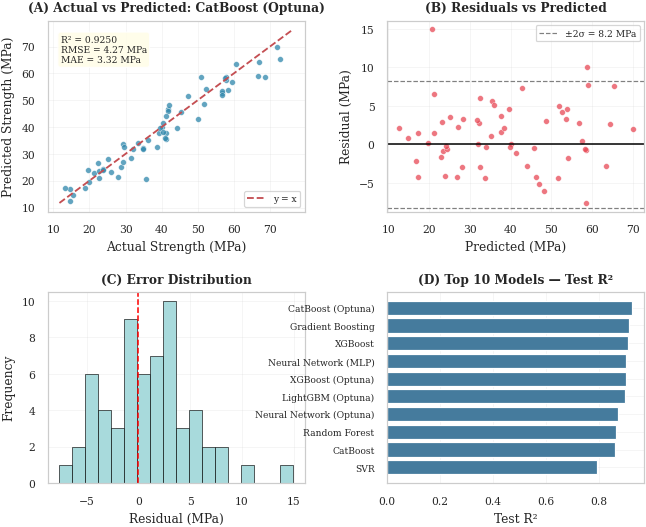

In [25]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 13: 4-Panel Publication Figure (A/B/C/D) — Journal Quality     ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("🖼️ CELL 13: Generating 4-panel publication-quality figure...")

best_name  = df_comp.iloc[0]['Model']
best_model = trained[best_name] if best_name in trained else list(trained.values())[0]
y_pred     = best_model.predict(X_test_sc)
res_plot   = y_test - y_pred
r2_best    = r2_score(y_test, y_pred)
rmse_best  = np.sqrt(mean_squared_error(y_test, y_pred))
mae_best   = mean_absolute_error(y_test, y_pred)

# Double-column 4-panel — fits 180 mm
fig = plt.figure(figsize=(COL_DOUBLE, COL_DOUBLE * 0.78))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# ── Panel A: Actual vs Predicted ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred, c='#2E86AB', s=14, alpha=0.75,
            edgecolors='white', linewidths=0.3)
lims = [min(y_test.min(), y_pred.min()) * 0.93,
        max(y_test.max(), y_pred.max()) * 1.05]
ax1.plot(lims, lims, 'r--', lw=1.2, label='y = x')
ax1.set_xlabel('Actual Strength (MPa)')
ax1.set_ylabel('Predicted Strength (MPa)')
ax1.set_title(f'(A) Actual vs Predicted: {best_name}',
              fontsize=8, fontweight='bold')
ax1.text(0.05, 0.78,
    f'R² = {r2_best:.4f}\nRMSE = {rmse_best:.2f} MPa\nMAE = {mae_best:.2f} MPa',
    transform=ax1.transAxes, fontsize=6,
    bbox=dict(boxstyle='round', facecolor='#fffde7', alpha=0.85))
ax1.legend(fontsize=6)

# ── Panel B: Residuals ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_pred, res_plot, c='#E84855', s=14, alpha=0.75,
            edgecolors='white', linewidths=0.3)
ax2.axhline(0, color='black', lw=1)
ax2.axhline( 2 * res_plot.std(), color='gray', lw=0.8, ls='--',
            label=f'±2σ = {2 * res_plot.std():.1f} MPa')
ax2.axhline(-2 * res_plot.std(), color='gray', lw=0.8, ls='--')
ax2.set_xlabel('Predicted (MPa)')
ax2.set_ylabel('Residual (MPa)')
ax2.set_title('(B) Residuals vs Predicted',
              fontsize=8, fontweight='bold')
ax2.legend(fontsize=6)

# ── Panel C: Error Distribution ───────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(res_plot, bins=18, color='#A8DADC', edgecolor='black', linewidth=0.4)
ax3.axvline(0, color='red', ls='--', lw=1)
ax3.set_xlabel('Residual (MPa)')
ax3.set_ylabel('Frequency')
ax3.set_title('(C) Error Distribution',
              fontsize=8, fontweight='bold')

# ── Panel D: Top-10 Models comparison ─────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
top10 = df_comp.head(10).iloc[::-1]
ax4.barh(top10['Model'], top10['R2_Test'], color='#457B9D', edgecolor='white') # Changed 'Test_R2' to 'R2_Test'
ax4.set_xlabel('Test R²')
ax4.set_title('(D) Top 10 Models — Test R²',
              fontsize=8, fontweight='bold')
ax4.tick_params(axis='y', labelsize=6)

plt.tight_layout()
save_pub('Fig_Publication_4Panel')
plt.show()

CELL 14 — SHAP Feature Importance (Original Features Only, 1200 DPI)


🔍 CELL 14: Computing SHAP feature importance (original features)...
   ✅ Saved figures_journal/Fig_SHAP_Importance.{png,tiff,pdf,svg}  @ 600 DPI


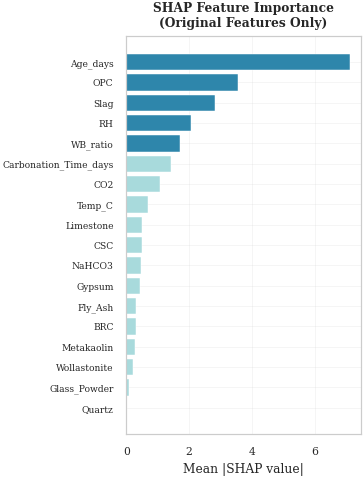

✅ Saved: figures_journal/SHAP_Importance_Table.xlsx


In [26]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 14: SHAP Feature Importance — Single-column journal figure    ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("🔍 CELL 14: Computing SHAP feature importance (original features)...")

shap_model = XGBRegressor(**studies['XGBoost'].best_params,
                          random_state=SEED, verbosity=0)
shap_model.fit(X_train_sc, y_train)

explainer = shap.TreeExplainer(shap_model)
shap_vals = explainer.shap_values(X_train_sc)
mean_shap = np.abs(shap_vals).mean(axis=0)

n_show  = min(len(ALL_FEATS), 18)
shap_df = (pd.DataFrame({'Feature': ALL_FEATS, 'SHAP': mean_shap})
             .sort_values('SHAP', ascending=False)
             .head(n_show)
             .reset_index(drop=True))

# Single-column tall figure
fig2, ax5 = plt.subplots(figsize=(COL_SINGLE, COL_SINGLE * 1.3))
colors_s = ['#2E86AB' if i < 5 else '#A8DADC' for i in range(n_show)]
ax5.barh(range(n_show), shap_df['SHAP'].values[::-1], color=colors_s[::-1],
         edgecolor='white', linewidth=0.3)
ax5.set_yticks(range(n_show))
ax5.set_yticklabels(shap_df['Feature'].values[::-1], fontsize=6)
ax5.set_xlabel('Mean |SHAP value|')
ax5.set_title('SHAP Feature Importance\n(Original Features Only)',
              fontsize=8, fontweight='bold')
plt.tight_layout()

save_pub('Fig_SHAP_Importance')
plt.show()

shap_df.round(4).to_excel(os.path.join(FIG_DIR, 'SHAP_Importance_Table.xlsx'), index=False)
print(f"✅ Saved: {FIG_DIR}/SHAP_Importance_Table.xlsx")


CELL 15 — Taylor Diagram (Top Models, 1200 DPI)

📈 CELL 15: Generating Taylor Diagram...
   ✅ Saved figures_journal/Fig_Taylor_Diagram.{png,tiff,pdf,svg}  @ 600 DPI


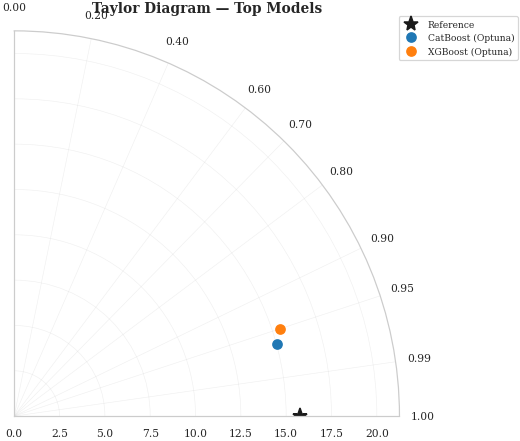

In [27]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 15: Taylor Diagram (Top Models) — Single-column journal figure║
# ╚══════════════════════════════════════════════════════════════════════╝
print("📈 CELL 15: Generating Taylor Diagram...")

def taylor_stats(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    std_ref  = np.std(y_true, ddof=1)
    std_pred = np.std(y_pred, ddof=1)
    corr     = np.corrcoef(y_true, y_pred)[0, 1]
    crmsd    = np.sqrt(np.mean(((y_pred - np.mean(y_pred))
                                - (y_true - np.mean(y_true))) ** 2))
    return std_ref, std_pred, corr, crmsd

TOP_N = 5
all_top_model_names = df_comp.head(TOP_N)['Model'].tolist()
top_models = [name for name in all_top_model_names if name in trained]

stats_list = []
for name in top_models:
    model = trained[name]
    y_pred_model = model.predict(X_test_sc)
    std_ref, std_pred, corr, crmsd = taylor_stats(y_test, y_pred_model)
    stats_list.append({'Model': name, 'STD_REF': std_ref,
                       'STD_PRED': std_pred, 'CORR': corr, 'CRMSD': crmsd})

std_ref = stats_list[0]['STD_REF'] if stats_list else np.std(y_test, ddof=1)

# 1.5-column figure
fig = plt.figure(figsize=(COL_1_5, COL_1_5 * 0.82))
ax = fig.add_subplot(111, polar=True)
ax.set_thetamin(0); ax.set_thetamax(90)

corr_ticks  = np.array([0.0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0])
theta_ticks = np.degrees(np.arccos(corr_ticks))
ax.set_thetagrids(theta_ticks,
                  labels=[f"{c:.2f}" if c < 1 else "1.00" for c in corr_ticks])

std_max = max([d['STD_PRED'] for d in stats_list] + [std_ref]) * 1.35
ax.set_rlim(0, std_max)

ax.plot(0, std_ref, 'k*', markersize=10, label='Reference')

palette = plt.cm.tab10.colors
for i, d in enumerate(stats_list):
    theta = np.arccos(np.clip(d['CORR'], -1, 1))
    ax.plot(theta, d['STD_PRED'], 'o',
            color=palette[i % len(palette)], markersize=6,
            label=d['Model'])

ax.set_title('Taylor Diagram — Top Models', fontsize=9, fontweight='bold', pad=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.32, 1.05), fontsize=6)
plt.tight_layout()

save_pub('Fig_Taylor_Diagram')
plt.show()


CELL 16 — SHAP Summary (Beeswarm) + Dependence Plots Using Original Features


🐝 CELL 16: Generating SHAP summary and dependence plots...
   ✅ Saved figures_journal/Fig_SHAP_Beeswarm.{png,tiff,pdf,svg}  @ 600 DPI


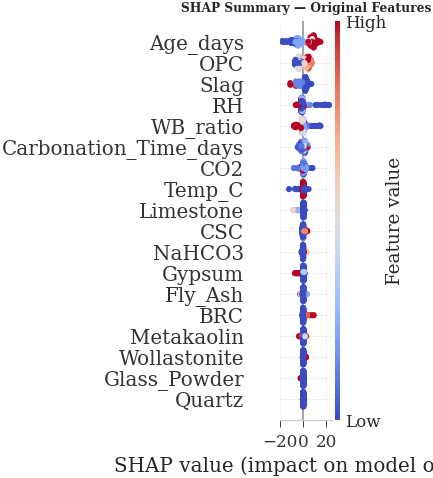

   ✅ Saved figures_journal/Fig_SHAP_Dependence.{png,tiff,pdf,svg}  @ 600 DPI


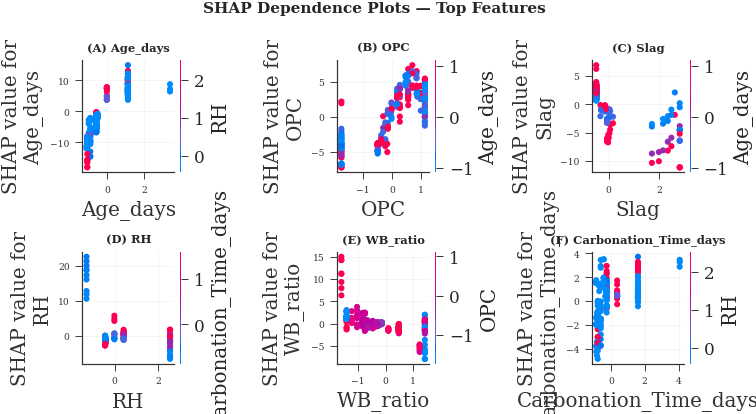

In [28]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 16: SHAP Beeswarm + Dependence Plots — Journal Quality        ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("🐝 CELL 16: Generating SHAP summary and dependence plots...")

# ── SHAP Beeswarm ─ single-column tall ────────────────────────────
fig = plt.figure(figsize=(COL_SINGLE * 1.1, COL_SINGLE * 1.3))
shap.summary_plot(
    shap_vals, features=X_train_sc,
    feature_names=ALL_FEATS,
    max_display=min(18, len(ALL_FEATS)),
    show=False, plot_size=None, cmap='coolwarm'
)
plt.title('SHAP Summary — Original Features',
          fontsize=8, fontweight='bold', pad=6)
plt.tight_layout()
save_pub('Fig_SHAP_Beeswarm')
plt.show()

# ── SHAP Dependence (top 6) ─ double-column ───────────────────────
top_features = shap_df['Feature'].head(min(6, len(shap_df))).tolist()
fig, axes = plt.subplots(2, 3, figsize=(COL_DOUBLE, COL_DOUBLE * 0.55))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    feat_idx = ALL_FEATS.index(feat)
    shap.dependence_plot(
        feat_idx, shap_vals, X_train_sc,
        feature_names=ALL_FEATS, ax=axes[i], show=False
    )
    axes[i].set_title(f'({chr(65+i)}) {feat}',
                      fontsize=7.5, fontweight='bold')
    axes[i].tick_params(axis='both', labelsize=6)

for j in range(len(top_features), len(axes)):
    axes[j].axis('off')

plt.suptitle('SHAP Dependence Plots — Top Features',
             fontsize=10, fontweight='bold', y=1.0)
plt.tight_layout()
save_pub('Fig_SHAP_Dependence')
plt.show()


CELL 17 — Permutation Importance + 3-Way Importance Comparison

🔀 CELL 17: Computing permutation importance (XGB native vs SHAP vs Perm)...
   ✅ Saved figures_journal/Fig_Importance_Comparison.{png,tiff,pdf,svg}  @ 600 DPI


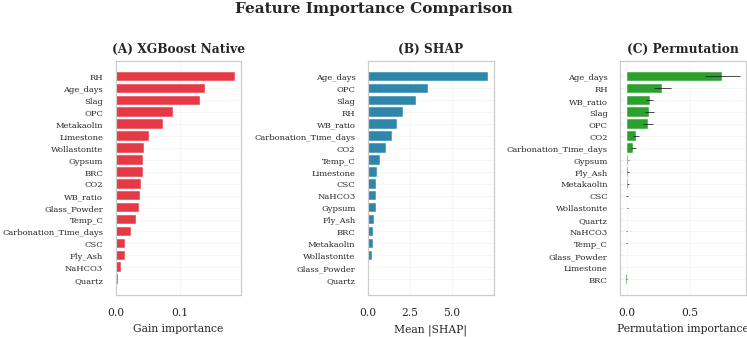

In [29]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 17: Permutation Importance & 3-Way Comparison — Double col    ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("🔀 CELL 17: Computing permutation importance (XGB native vs SHAP vs Perm)...")

from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    shap_model, X_test_sc, y_test,
    n_repeats=30, random_state=SEED, n_jobs=-1, scoring='r2'
)

perm_df = pd.DataFrame({
    'Feature'  : ALL_FEATS,
    'Perm_Mean': perm_result.importances_mean,
    'Perm_Std' : perm_result.importances_std
}).sort_values('Perm_Mean', ascending=False).head(20).reset_index(drop=True)

xgb_imp = pd.DataFrame({
    'Feature' : ALL_FEATS,
    'XGB_Gain': shap_model.feature_importances_
}).sort_values('XGB_Gain', ascending=False).head(20).reset_index(drop=True)

# Double-column 1×3 panel
fig, axes = plt.subplots(1, 3, figsize=(COL_DOUBLE, COL_DOUBLE * 0.45))

# Panel A
axes[0].barh(range(len(xgb_imp)), xgb_imp['XGB_Gain'].values[::-1],
             color='#E63946', edgecolor='white', linewidth=0.3)
axes[0].set_yticks(range(len(xgb_imp)))
axes[0].set_yticklabels(xgb_imp['Feature'].values[::-1], fontsize=5.5)
axes[0].set_xlabel('Gain importance', fontsize=7)
axes[0].set_title('(A) XGBoost Native', fontsize=8, fontweight='bold')

# Panel B
top20_shap = shap_df.head(20)
axes[1].barh(range(len(top20_shap)), top20_shap['SHAP'].values[::-1],
             color='#2E86AB', edgecolor='white', linewidth=0.3)
axes[1].set_yticks(range(len(top20_shap)))
axes[1].set_yticklabels(top20_shap['Feature'].values[::-1], fontsize=5.5)
axes[1].set_xlabel('Mean |SHAP|', fontsize=7)
axes[1].set_title('(B) SHAP', fontsize=8, fontweight='bold')

# Panel C
axes[2].barh(range(len(perm_df)), perm_df['Perm_Mean'].values[::-1],
             xerr=perm_df['Perm_Std'].values[::-1],
             color='#2CA02C', edgecolor='white', linewidth=0.3,
             error_kw={'linewidth': 0.5})
axes[2].set_yticks(range(len(perm_df)))
axes[2].set_yticklabels(perm_df['Feature'].values[::-1], fontsize=5.5)
axes[2].set_xlabel('Permutation importance', fontsize=7)
axes[2].set_title('(C) Permutation', fontsize=8, fontweight='bold')

plt.suptitle('Feature Importance Comparison',
             fontsize=10, fontweight='bold', y=1.0)
plt.tight_layout()

save_pub('Fig_Importance_Comparison')
plt.show()


CELL 18 — Partial Dependence Plots (PDP) for Top Original Features


📈 CELL 18: Generating Partial Dependence Plots...
   ✅ Saved figures_journal/Fig_PDP_Plots.{png,tiff,pdf,svg}  @ 600 DPI


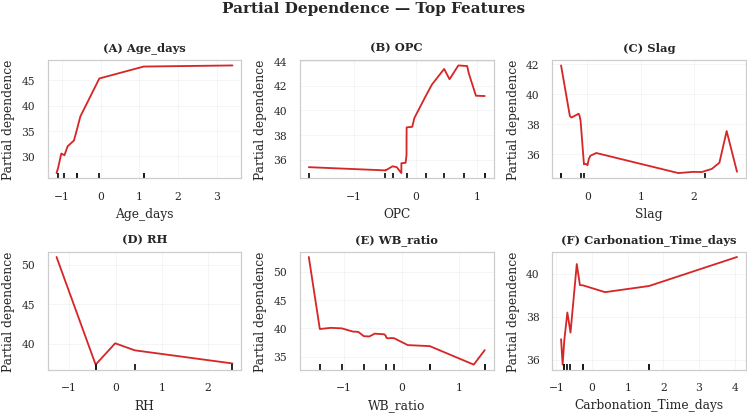

In [30]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 18: Partial Dependence Plots (PDP) — Double-column journal    ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("📈 CELL 18: Generating Partial Dependence Plots...")

from sklearn.inspection import PartialDependenceDisplay

top_pdp_features = shap_df['Feature'].head(min(6, len(shap_df))).tolist()
top_pdp_indices  = [ALL_FEATS.index(f) for f in top_pdp_features]

fig, axes = plt.subplots(2, 3, figsize=(COL_DOUBLE, COL_DOUBLE * 0.55))
axes = axes.flatten()

for i, (feat_name, feat_idx) in enumerate(zip(top_pdp_features, top_pdp_indices)):
    PartialDependenceDisplay.from_estimator(
        shap_model, X_train_sc, features=[feat_idx],
        feature_names=ALL_FEATS, ax=axes[i],
        line_kw={'color': '#D62728', 'linewidth': 1.2},
        grid_resolution=50
    )
    axes[i].set_title(f'({chr(65+i)}) {feat_name}',
                      fontsize=7.5, fontweight='bold')
    axes[i].tick_params(axis='both', labelsize=6)
    axes[i].grid(alpha=0.3)

for j in range(len(top_pdp_features), len(axes)):
    axes[j].axis('off')

plt.suptitle('Partial Dependence — Top Features',
             fontsize=10, fontweight='bold', y=1.0)
plt.tight_layout()

save_pub('Fig_PDP_Plots')
plt.show()


CELL 19 — Learning Curve + Error Distribution + Q-Q Plot

📚 CELL 19: Generating learning curve, error histogram, Q-Q plot...
   Computing learning curve (~1-2 min)...
   ✅ Saved figures_journal/Fig_Model_Diagnostics.{png,tiff,pdf,svg}  @ 600 DPI


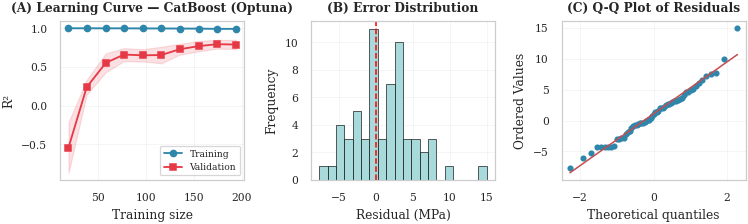

In [31]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 19: Learning Curve + Error Histogram + Q-Q Plot — Double col  ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("📚 CELL 19: Generating learning curve, error histogram, Q-Q plot...")

from sklearn.model_selection import learning_curve
from scipy import stats as scipy_stats

best_name  = df_comp.iloc[0]['Model']
best_model = trained[best_name] if best_name in trained else list(trained.values())[0]

print("   Computing learning curve (~1-2 min)...")
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_sc, y_train,
    cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1, random_state=SEED
)
train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean,   val_std   = val_scores.mean(axis=1),   val_scores.std(axis=1)

y_pred_best = best_model.predict(X_test_sc)
residuals   = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(COL_DOUBLE, COL_DOUBLE * 0.32))

# Panel A — Learning curve
axes[0].plot(train_sizes, train_mean, 'o-', color='#2E86AB',
             label='Training', linewidth=1.2, markersize=4)
axes[0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                     alpha=0.15, color='#2E86AB')
axes[0].plot(train_sizes, val_mean, 's-', color='#E63946',
             label='Validation', linewidth=1.2, markersize=4)
axes[0].fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                     alpha=0.15, color='#E63946')
axes[0].set_xlabel('Training size')
axes[0].set_ylabel('R²')
axes[0].set_title(f'(A) Learning Curve — {best_name}',
                  fontsize=8, fontweight='bold')
axes[0].legend(fontsize=6)
axes[0].grid(alpha=0.3)

# Panel B — Error histogram
axes[1].hist(residuals, bins=20, color='#A8DADC',
             edgecolor='black', linewidth=0.4)
axes[1].axvline(0, color='red', ls='--', lw=1)
axes[1].set_xlabel('Residual (MPa)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('(B) Error Distribution',
                  fontsize=8, fontweight='bold')

# Panel C — Q-Q plot
scipy_stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('(C) Q-Q Plot of Residuals',
                  fontsize=8, fontweight='bold')
axes[2].get_lines()[0].set_markersize(3)
axes[2].get_lines()[0].set_color('#2E86AB')
axes[2].get_lines()[1].set_linewidth(1)

plt.tight_layout()
save_pub('Fig_Model_Diagnostics')
plt.show()


CELL 20 — All Models: Predicted vs Actual Grid (Top 6)

🎯 CELL 20: Generating predicted-vs-actual grid for top 6 models...
   ✅ Saved figures_journal/Fig_AllModels_PredVsActual.{png,tiff,pdf,svg}  @ 600 DPI


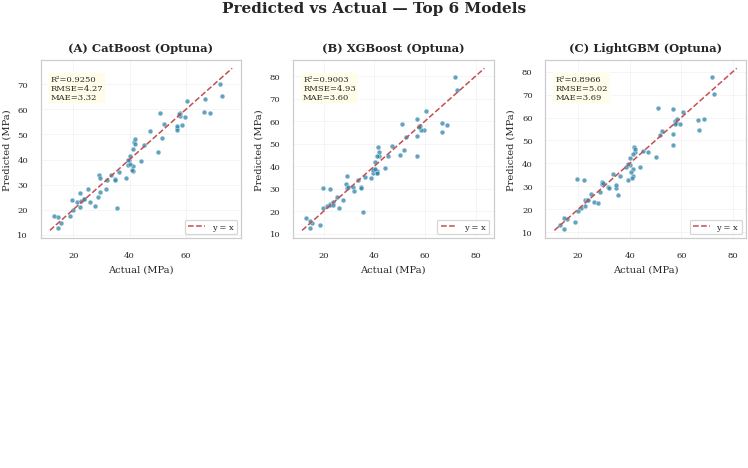

In [32]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 20: Predicted vs Actual — Top 6 Models Grid — Double-col      ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("🎯 CELL 20: Generating predicted-vs-actual grid for top 6 models...")

top6_names = [n for n in df_comp.head(6)['Model'].tolist() if n in trained][:6]

fig, axes = plt.subplots(2, 3, figsize=(COL_DOUBLE, COL_DOUBLE * 0.62))
axes = axes.flatten()

for i, name in enumerate(top6_names):
    mdl   = trained[name]
    yp    = mdl.predict(X_test_sc)
    r2_i  = r2_score(y_test, yp)
    rms_i = np.sqrt(mean_squared_error(y_test, yp))
    mae_i = mean_absolute_error(y_test, yp)

    axes[i].scatter(y_test, yp, c='#2E86AB', s=10, alpha=0.75,
                    edgecolors='white', linewidths=0.3)
    lims = [min(y_test.min(), yp.min()) * 0.93,
            max(y_test.max(), yp.max()) * 1.05]
    axes[i].plot(lims, lims, 'r--', lw=1, label='y = x')
    axes[i].set_xlabel('Actual (MPa)', fontsize=6.5)
    axes[i].set_ylabel('Predicted (MPa)', fontsize=6.5)
    axes[i].set_title(f'({chr(65+i)}) {name}', fontsize=7.5, fontweight='bold')
    axes[i].text(0.05, 0.78,
                 f'R²={r2_i:.4f}\nRMSE={rms_i:.2f}\nMAE={mae_i:.2f}',
                 transform=axes[i].transAxes, fontsize=5.5,
                 bbox=dict(boxstyle='round', facecolor='#fffde7', alpha=0.85))
    axes[i].legend(fontsize=5.5, loc='lower right')
    axes[i].grid(alpha=0.3)
    axes[i].tick_params(axis='both', labelsize=5.5)

for j in range(len(top6_names), 6):
    axes[j].axis('off')

plt.suptitle('Predicted vs Actual — Top 6 Models',
             fontsize=10, fontweight='bold', y=1.0)
plt.tight_layout()

save_pub('Fig_AllModels_PredVsActual')
plt.show()


CELL 21 — Optuna Optimization History & Hyperparameter Importance

⚙️ CELL 21: Generating Optuna optimization visualizations...
   ✅ Saved figures_journal/Fig_Optuna_Optimization.{png,tiff,pdf,svg}  @ 600 DPI


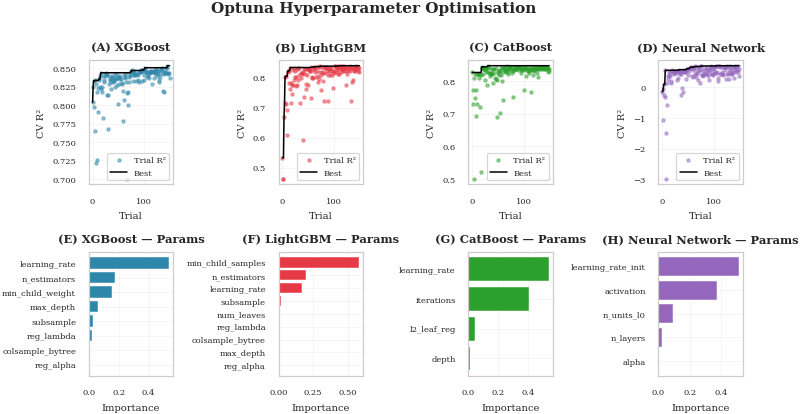

In [33]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 21: Optuna Optimization History + Param Importance — Double  ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("⚙️ CELL 21: Generating Optuna optimization visualizations...")

import optuna

fig, axes = plt.subplots(2, 4, figsize=(COL_DOUBLE, COL_DOUBLE * 0.55))

model_names = ['XGBoost', 'LightGBM', 'CatBoost', 'Neural Network']
colors_opt  = ['#2E86AB', '#E63946', '#2CA02C', '#9467BD']

for col, (name, color) in enumerate(zip(model_names, colors_opt)):
    study = studies[name]

    # Top row — optimisation history
    values      = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.maximum.accumulate(values)
    axes[0, col].plot(range(len(values)), values, 'o',
                      color=color, markersize=2, alpha=0.45,
                      label='Trial R²')
    axes[0, col].plot(range(len(best_so_far)), best_so_far,
                      '-', color='black', lw=1, label='Best')
    axes[0, col].set_xlabel('Trial', fontsize=6.5)
    axes[0, col].set_ylabel('CV R²', fontsize=6.5)
    axes[0, col].set_title(f'({chr(65+col)}) {name}',
                           fontsize=7.5, fontweight='bold')
    axes[0, col].legend(fontsize=5.5)
    axes[0, col].grid(alpha=0.3)
    axes[0, col].tick_params(axis='both', labelsize=5.5)

    # Bottom row — hyperparameter importance
    try:
        param_imp = optuna.importance.get_param_importances(study)
        params = list(param_imp.keys())
        imps   = list(param_imp.values())
        axes[1, col].barh(range(len(params)), imps[::-1],
                          color=color, edgecolor='white', linewidth=0.3)
        axes[1, col].set_yticks(range(len(params)))
        axes[1, col].set_yticklabels(params[::-1], fontsize=5.5)
        axes[1, col].set_xlabel('Importance', fontsize=6.5)
        axes[1, col].set_title(f'({chr(69+col)}) {name} — Params',
                               fontsize=7.5, fontweight='bold')
        axes[1, col].tick_params(axis='x', labelsize=5.5)
    except Exception as e:
        axes[1, col].text(0.5, 0.5, f'Param importance\nunavailable\n({e})',
                          ha='center', va='center',
                          transform=axes[1, col].transAxes, fontsize=6)
        axes[1, col].axis('off')

plt.suptitle('Optuna Hyperparameter Optimisation',
             fontsize=10, fontweight='bold', y=1.0)
plt.tight_layout()

save_pub('Fig_Optuna_Optimization')
plt.show()


CELL 22 — Stacking Ensemble (Often Beats the Best Single Model)

In [35]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 22: Stacking Ensemble - Optimized for Speed and Stability      ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("🏗️ CELL 22: Building a stacking ensemble...")

from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
import gc

# 1. Ensure base models are set to single-thread mode
# This prevents them from fighting the Stacker for CPU cores
for name, model in tuned_models.items():
    if hasattr(model, 'n_jobs'):
        model.set_params(n_jobs=1)
    if hasattr(model, 'thread_count'):
        model.set_params(thread_count=1)

base_estimators = [
    ('xgb', tuned_models['XGBoost (Optuna)']),
    ('lgb', tuned_models['LightGBM (Optuna)']),
    ('cat', tuned_models['CatBoost (Optuna)']),
    ('nn',  tuned_models['Neural Network (Optuna)']),
]

# 2. Build Stacker with n_jobs=1
stack_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=KFold(n_splits=10, shuffle=True, random_state=SEED),
    n_jobs=1,  # CRITICAL: Do not use -1 for small datasets
    passthrough=False
)

print("   Training stacking ensemble (should finish in < 45 seconds)...")
stack_model.fit(X_train_sc, y_train)

# 3. Evaluation
y_pred_stack = stack_model.predict(X_test_sc)
r2_stack    = r2_score(y_test, y_pred_stack)
rmse_stack  = np.sqrt(mean_squared_error(y_test, y_pred_stack))
mae_stack   = mean_absolute_error(y_test, y_pred_stack)

# 4. Cross-validation with n_jobs=1
print("   Performing final cross-validation...")
cv_stack = cross_val_score(stack_model, X_train_sc, y_train,
                           cv=KFold(5, shuffle=True, random_state=SEED),
                           scoring='r2', n_jobs=1) # CRITICAL: Do not use -1

# --- (Rest of your leaderboard code) ---
print("\n" + "=" * 60)
print(f"{'🏗️ STACKING ENSEMBLE RESULTS':^60}")
print("=" * 60)
print(f"   Test R²   : {r2_stack:.4f}")
print(f"   CV R²     : {cv_stack.mean():.4f} ± {cv_stack.std():.4f}")
print(f"   RMSE      : {rmse_stack:.3f} MPa")
print(f"   MAE       : {mae_stack:.3f} MPa")
print("=" * 60)

# Add to leaderboard and save
stack_row = pd.DataFrame([{
    'Model'   : 'Stacking Ensemble',
    'R2_Test' : round(r2_stack, 4),
    'CV_R2'   : round(cv_stack.mean(), 4),
    'CV_Std'  : round(cv_stack.std(),  4),
    'RMSE'    : round(rmse_stack, 3),
    'MAE'     : round(mae_stack,  3),
}])

df_comp_final = pd.concat([df_comp.reset_index(drop=True), stack_row], ignore_index=True)
df_comp_final = df_comp_final.sort_values('R2_Test', ascending=False).reset_index(drop=True)
df_comp_final.index += 1
trained['Stacking Ensemble'] = stack_model

print("\n🏆 FINAL LEADERBOARD:")
print(df_comp_final.to_string())
df_comp_final.to_excel('Publication_Table_Final.xlsx', index=True)
print("\n✅ Saved: Publication_Table_Final.xlsx")

🏗️ CELL 22: Building a stacking ensemble...
   Training stacking ensemble (should finish in < 45 seconds)...
   Performing final cross-validation...

                🏗️ STACKING ENSEMBLE RESULTS                
   Test R²   : 0.9194
   CV R²     : 0.8189 ± 0.0566
   RMSE      : 4.433 MPa
   MAE       : 3.326 MPa

🏆 FINAL LEADERBOARD:
                      Model  R2_Train   R2_Test       RMSE       MAE     CV_R2    CV_Std
1         CatBoost (Optuna)       NaN  0.925005   4.274778  3.315768  0.846709  0.089960
2         Stacking Ensemble       NaN  0.919400   4.433000  3.326000  0.818900  0.056600
3         Gradient Boosting    0.9589  0.912500   4.618300  3.639500       NaN       NaN
4                   XGBoost    0.9840  0.907500   4.746700  3.441900       NaN       NaN
5      Neural Network (MLP)    0.9374  0.901600   4.896300  3.862300       NaN       NaN
6          XGBoost (Optuna)       NaN  0.900275   4.929455  3.602437  0.853594  0.079807
7         LightGBM (Optuna)       NaN  0.

CELL 23 — Export Predictions + Save Best Model (Reproducibility)

In [39]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 23: Export Predictions & Save Trained Models (Reproducibility) ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("💾 CELL 23: Exporting predictions and saving best trained model...")

import joblib

# ── 1. Export predictions for ALL models on test set ──────────────
predictions_df = pd.DataFrame({'Actual (MPa)': y_test})
for name, mdl in trained.items():
    predictions_df[f'Pred_{name}'] = mdl.predict(X_test_sc)
    predictions_df[f'Error_{name}'] = y_test - predictions_df[f'Pred_{name}']

predictions_df.round(4).to_excel('Test_Predictions_AllModels.xlsx', index=False)
print(f"✅ Saved: Test_Predictions_AllModels.xlsx  ({predictions_df.shape[0]} rows)")

# ── 2. Save the best model (and stacking) via joblib ──────────────
best_name_final  = df_comp_final.iloc[0]['Model']
best_model_final = trained[best_name_final]

joblib.dump(best_model_final, 'Best_Model.joblib')
joblib.dump(scaler,           'Scaler.joblib')
joblib.dump(ALL_FEATS,        'Feature_Names.joblib')
print(f"✅ Saved: Best_Model.joblib  ({best_name_final})")
print("✅ Saved: Scaler.joblib")
print("✅ Saved: Feature_Names.joblib")

# ── 3. Quick inference demo (how a future user would reuse it) ────
print("\n--- 🔁 Reproducibility demo: load & predict 3 samples ---")
loaded_model  = joblib.load('Best_Model.joblib')
loaded_scaler = joblib.load('Scaler.joblib')
demo_pred     = loaded_model.predict(loaded_scaler.transform(X_test[:3]))
for i in range(3):
    print(f"  Sample {i+1}: Actual = {y_test[i]:7.2f} MPa  |  "
          f"Predicted = {demo_pred[i]:7.2f} MPa")


💾 CELL 23: Exporting predictions and saving best trained model...
✅ Saved: Test_Predictions_AllModels.xlsx  (61 rows)
✅ Saved: Best_Model.joblib  (CatBoost (Optuna))
✅ Saved: Scaler.joblib
✅ Saved: Feature_Names.joblib

--- 🔁 Reproducibility demo: load & predict 3 samples ---
  Sample 1: Actual =   15.54 MPa  |  Predicted =   14.72 MPa
  Sample 2: Actual =   22.55 MPa  |  Predicted =   21.10 MPa
  Sample 3: Actual =   14.65 MPa  |  Predicted =   16.85 MPa


CELL 24 — Radar Chart: Multi-Metric Comparison of Top Models

🕸️ CELL 24: Generating radar chart of top 5 models...
   ✅ Saved figures_journal/Fig_Radar_TopModels.{png,tiff,pdf,svg}  @ 600 DPI


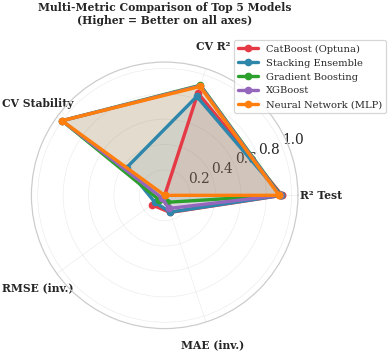

✅ Saved: Radar_TopModels.png / .tiff / .pdf  (1200 DPI)


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("🕸️ CELL 24: Generating radar chart of top 5 models...")

top5 = df_comp_final.head(5).reset_index(drop=True)

# Metrics (higher = better). Invert RMSE and MAE so larger means better on radar.
rmse_max = top5['RMSE'].max()
mae_max  = top5['MAE'].max()

metrics_df = pd.DataFrame({
    'Model'          : top5['Model'],
    'R² Test'        : top5['R2_Test'],
    'CV R²'          : top5['CV_R2'].fillna(top5['R2_Test']),
    'CV Stability'   : 1 - top5['CV_Std'].fillna(0) / (top5['CV_Std'].fillna(0).max() + 1e-9),
    'RMSE (inv.)'    : 1 - top5['RMSE'] / (rmse_max + 1e-9),
    'MAE (inv.)'     : 1 - top5['MAE']  / (mae_max  + 1e-9),
})

categories = ['R² Test', 'CV R²', 'CV Stability', 'RMSE (inv.)', 'MAE (inv.)']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(COL_SINGLE * 1.1, COL_SINGLE * 1.1), subplot_kw=dict(polar=True))

palette = ['#E63946', '#2E86AB', '#2CA02C', '#9467BD', '#FF7F0E']

for i, row in metrics_df.iterrows():
    values = row[categories].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2.2,
            label=row['Model'], color=palette[i % len(palette)])
    ax.fill(angles, values, alpha=0.1, color=palette[i % len(palette)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=7, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
ax.grid(alpha=0.4)

ax.set_title('Multi-Metric Comparison of Top 5 Models\n(Higher = Better on all axes)',
             fontsize=7, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=6.5)

plt.tight_layout()
save_pub('Fig_Radar_TopModels', pil_kwargs={'compression': 'tiff_lzw'})
plt.show()

print("✅ Saved: Radar_TopModels.png / .tiff / .pdf  (1200 DPI)")

CELL 25 — UPDATED: Download ALL Output Files

In [50]:

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  EXTRA CELL: Export plot data to Excel for Origin redraw             ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("📦 EXTRA CELL: Exporting plot data for Origin, one Excel file for each main figure...")

import os
import re
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from scipy import stats as scipy_stats
from sklearn.inspection import partial_dependence
import optuna

PLOT_DATA_FILES = []

def _safe_sheet_name(name):
    name = re.sub(r'[\[\]\:\*\?\/\\]', '_', str(name))
    return name[:31] if len(name) > 31 else name

def export_excel_bundle(file_name, sheets_dict):
    clean_sheets = {}
    used = set()
    for raw_name, obj in sheets_dict.items():
        sheet_name = _safe_sheet_name(raw_name)
        if sheet_name in used:
            base = sheet_name[:28]
            k = 1
            while f"{base}_{k}" in used:
                k += 1
            sheet_name = f"{base}_{k}"
        used.add(sheet_name)

        if isinstance(obj, pd.Series):
            df_out = obj.to_frame()
        else:
            df_out = pd.DataFrame(obj).copy()

        if isinstance(df_out.index, pd.RangeIndex):
            df_out = df_out.reset_index(drop=True)
        else:
            df_out = df_out.reset_index()

        clean_sheets[sheet_name] = df_out

    with pd.ExcelWriter(file_name, engine='openpyxl') as writer:
        for sheet_name, df_out in clean_sheets.items():
            df_out.to_excel(writer, sheet_name=sheet_name, index=False)

    PLOT_DATA_FILES.append(file_name)
    print(f"✅ Saved: {file_name}")

# ── 1. Correlation matrix ──────────────────────────────────────────────
export_excel_bundle(
    'Correlation_Matrix_Data.xlsx',
    {
        'Correlation_Matrix': corr_matrix
    }
)

# ── 2. Distribution data (raw + histogram bins) ───────────────────────
dist_columns = ORIGINAL_FEATURES + [TARGET]
dist_sheets = {
    'Raw_Data': df_raw[dist_columns]
}
for col in dist_columns:
    vals = df_raw[col].dropna().astype(float).values
    counts, edges = np.histogram(vals, bins=20)
    dist_sheets[f'Hist_{col}'] = pd.DataFrame({
        'Bin_Left': edges[:-1],
        'Bin_Right': edges[1:],
        'Bin_Center': (edges[:-1] + edges[1:]) / 2,
        'Count': counts
    })

export_excel_bundle('Distributions_Pastel_Data.xlsx', dist_sheets)

# ── 3. KDE distribution data (raw + density curve) ────────────────────
kde_sheets = {
    'Raw_Data_18Features': df_raw[ORIGINAL_FEATURES]
}
for col in ORIGINAL_FEATURES:
    vals = df_raw[col].dropna().astype(float).values
    x_grid = np.linspace(vals.min(), vals.max(), 200)
    kde = gaussian_kde(vals)
    hist_density, hist_edges = np.histogram(vals, bins=20, density=True)
    kde_sheets[f'KDE_{col}'] = pd.DataFrame({
        'X': x_grid,
        'KDE_Density': kde(x_grid)
    })
    kde_sheets[f'HistDens_{col}'] = pd.DataFrame({
        'Bin_Left': hist_edges[:-1],
        'Bin_Right': hist_edges[1:],
        'Bin_Center': (hist_edges[:-1] + hist_edges[1:]) / 2,
        'Density': hist_density
    })

export_excel_bundle('Feature_Distribution_KDE_Data.xlsx', kde_sheets)

# ── 4. Publication 4-panel figure source data ─────────────────────────
pub_sheets = {}

best_name_pub = df_comp.iloc[0]['Model']
best_model_pub = trained[best_name_pub] if best_name_pub in trained else list(trained.values())[0]
y_pred_pub = best_model_pub.predict(X_test_sc)
res_pub = y_test - y_pred_pub

pub_sheets['Actual_vs_Pred'] = pd.DataFrame({
    'Actual_Strength_MPa': y_test,
    'Predicted_Strength_MPa': y_pred_pub
})
pub_sheets['Residual_Plot'] = pd.DataFrame({
    'Predicted_Strength_MPa': y_pred_pub,
    'Residual_MPa': res_pub
})
pub_sheets['Top15_R2'] = df_comp.head(15)[['Model', 'R2_Test', 'RMSE', 'MAE']].copy()

all_top_model_names_pub = df_comp.head(5)['Model'].tolist()
top5_names_pub = [name for name in all_top_model_names_pub if name in trained]
if top5_names_pub:
    cv_long_records = []
    for nm in top5_names_pub:
        scores = cross_val_score(
            trained[nm], X_train_sc, y_train,
            cv=KFold(10, shuffle=True, random_state=SEED),
            scoring='r2', n_jobs=-1
        )
        for fold_idx, score in enumerate(scores, start=1):
            cv_long_records.append({
                'Model': nm,
                'Fold': fold_idx,
                'CV_R2': score
            })
    pub_sheets['CV_Stability_Top5'] = pd.DataFrame(cv_long_records)

export_excel_bundle('Publication_Figure_Data.xlsx', pub_sheets)

# ── 5. SHAP importance data ────────────────────────────────────────────
export_excel_bundle(
    'SHAP_Importance_Data.xlsx',
    {
        'SHAP_Importance': shap_df
    }
)

# ── 6. Taylor diagram source data ─────────────────────────────────────
taylor_df = pd.DataFrame(stats_list).copy()
if not taylor_df.empty:
    taylor_df['Theta_Rad'] = np.arccos(np.clip(taylor_df['CORR'], -1, 1))
    taylor_df['Theta_Deg'] = np.degrees(taylor_df['Theta_Rad'])
    taylor_df['Reference_STD'] = std_ref

theta_ref = np.linspace(0, np.pi / 2, 300)
reference_arc_df = pd.DataFrame({
    'Theta_Rad': theta_ref,
    'Theta_Deg': np.degrees(theta_ref),
    'Reference_STD': np.full_like(theta_ref, std_ref, dtype=float)
})

export_excel_bundle(
    'Taylor_Diagram_Data.xlsx',
    {
        'Taylor_Stats': taylor_df,
        'Reference_Arc': reference_arc_df
    }
)

# ── 7. SHAP beeswarm source data ──────────────────────────────────────
X_train_raw_df = pd.DataFrame(X_train, columns=ALL_FEATS)
X_train_sc_df  = pd.DataFrame(X_train_sc, columns=ALL_FEATS)
shap_vals_df   = pd.DataFrame(shap_vals, columns=[f'SHAP_{c}' for c in ALL_FEATS])

export_excel_bundle(
    'SHAP_Beeswarm_Data.xlsx',
    {
        'X_Train_Raw': X_train_raw_df,
        'X_Train_Scaled': X_train_sc_df,
        'SHAP_Values': shap_vals_df
    }
)

# ── 8. SHAP dependence data for top features ───────────────────────────
dep_sheets = {}
top_features_dep = shap_df['Feature'].head(min(6, len(shap_df))).tolist()
for feat in top_features_dep:
    feat_idx = ALL_FEATS.index(feat)
    dep_sheets[f'Dep_{feat}'] = pd.DataFrame({
        'Feature_Value_Raw': X_train[:, feat_idx],
        'Feature_Value_Scaled': X_train_sc[:, feat_idx],
        'SHAP_Value': shap_vals[:, feat_idx]
    })

export_excel_bundle('SHAP_Dependence_Data.xlsx', dep_sheets)

# ── 9. Importance comparison data ─────────────────────────────────────
export_excel_bundle(
    'Importance_Comparison_Data.xlsx',
    {
        'XGB_Native': xgb_imp,
        'SHAP_Importance': shap_df.head(20),
        'Permutation': perm_df
    }
)

# ── 10. Partial dependence data ────────────────────────────────────────
pdp_sheets = {}
top_pdp_features_export = shap_df['Feature'].head(min(6, len(shap_df))).tolist()
for feat_name in top_pdp_features_export:
    feat_idx = ALL_FEATS.index(feat_name)
    pdp_res = partial_dependence(
        shap_model,
        X_train_sc,
        features=[feat_idx],
        grid_resolution=50
    )
    x_vals = pdp_res['grid_values'][0]
    y_vals = pdp_res['average'][0]
    pdp_sheets[f'PDP_{feat_name}'] = pd.DataFrame({
        'Feature_Value_Scaled': x_vals,
        'Partial_Dependence': y_vals
    })

export_excel_bundle('PDP_Plots_Data.xlsx', pdp_sheets)

# ── 11. Diagnostics data ───────────────────────────────────────────────
best_name_diag = df_comp.iloc[0]['Model']
best_model_diag = trained[best_name_diag] if best_name_diag in trained else list(trained.values())[0]

train_sizes_diag, train_scores_diag, val_scores_diag = learning_curve(
    best_model_diag, X_train_sc, y_train,
    cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1, random_state=SEED
)

train_mean_diag = train_scores_diag.mean(axis=1)
train_std_diag  = train_scores_diag.std(axis=1)
val_mean_diag   = val_scores_diag.mean(axis=1)
val_std_diag    = val_scores_diag.std(axis=1)

y_pred_diag = best_model_diag.predict(X_test_sc)
residuals_diag = y_test - y_pred_diag
(osm, osr), (slope_qq, intercept_qq, r_qq) = scipy_stats.probplot(residuals_diag, dist='norm')

export_excel_bundle(
    'Model_Diagnostics_Data.xlsx',
    {
        'Learning_Curve': pd.DataFrame({
            'Train_Size': train_sizes_diag,
            'Train_Mean_R2': train_mean_diag,
            'Train_Std_R2': train_std_diag,
            'Validation_Mean_R2': val_mean_diag,
            'Validation_Std_R2': val_std_diag
        }),
        'Residuals': pd.DataFrame({
            'Actual_Strength_MPa': y_test,
            'Predicted_Strength_MPa': y_pred_diag,
            'Residual_MPa': residuals_diag
        }),
        'QQ_Plot': pd.DataFrame({
            'Theoretical_Quantiles': osm,
            'Sample_Quantiles': osr,
            'Fit_Line_Y': slope_qq * osm + intercept_qq
        })
    }
)

# ── 12. Predicted vs actual for top 6 models ───────────────────────────
pred_grid_sheets = {}
top6_names_export = [n for n in df_comp.head(6)['Model'].tolist() if n in trained][:6]
for name in top6_names_export:
    yp_export = trained[name].predict(X_test_sc)
    pred_grid_sheets[name[:31]] = pd.DataFrame({
        'Actual_Strength_MPa': y_test,
        'Predicted_Strength_MPa': yp_export,
        'Error_MPa': y_test - yp_export
    })

export_excel_bundle('AllModels_PredVsActual_Data.xlsx', pred_grid_sheets)

# ── 13. Optuna history and parameter importance ────────────────────────
optuna_sheets = {}
model_names_export = ['XGBoost', 'LightGBM', 'CatBoost', 'Neural Network']
label_map = {
    'XGBoost': 'XGB',
    'LightGBM': 'LGBM',
    'CatBoost': 'CAT',
    'Neural Network': 'NN'
}
for name in model_names_export:
    study = studies[name]
    values = [t.value for t in study.trials if t.value is not None]
    hist_df = pd.DataFrame({
        'Trial': np.arange(1, len(values) + 1),
        'CV_R2': values,
        'Best_So_Far': np.maximum.accumulate(values) if len(values) else []
    })
    optuna_sheets[f'Hist_{label_map[name]}'] = hist_df

    try:
        param_imp = optuna.importance.get_param_importances(study)
        param_df = pd.DataFrame({
            'Parameter': list(param_imp.keys()),
            'Importance': list(param_imp.values())
        })
    except Exception:
        param_df = pd.DataFrame({'Parameter': [], 'Importance': []})

    optuna_sheets[f'Param_{label_map[name]}'] = param_df

export_excel_bundle('Optuna_Optimization_Data.xlsx', optuna_sheets)

# ── 14. Radar chart data ───────────────────────────────────────────────
top5_radar = df_comp_final.head(5).reset_index(drop=True)

rmse_max_radar = top5_radar['RMSE'].max()
mae_max_radar  = top5_radar['MAE'].max()

metrics_df_export = pd.DataFrame({
    'Model'        : top5_radar['Model'],
    'R2_Test'      : top5_radar['R2_Test'],
    'CV_R2'        : top5_radar['CV_R2'].fillna(top5_radar['R2_Test']),
    'CV_Stability' : 1 - top5_radar['CV_Std'].fillna(0) / (top5_radar['CV_Std'].fillna(0).max() + 1e-9),
    'RMSE_inv'     : 1 - top5_radar['RMSE'] / (rmse_max_radar + 1e-9),
    'MAE_inv'      : 1 - top5_radar['MAE']  / (mae_max_radar  + 1e-9),
})

radar_long_records = []
radar_categories = ['R2_Test', 'CV_R2', 'CV_Stability', 'RMSE_inv', 'MAE_inv']
angles_radar = np.linspace(0, 2 * np.pi, len(radar_categories), endpoint=False)

for _, row in metrics_df_export.iterrows():
    for cat, ang in zip(radar_categories, angles_radar):
        radar_long_records.append({
            'Model': row['Model'],
            'Metric': cat,
            'Value': row[cat],
            'Angle_Rad': ang,
            'Angle_Deg': np.degrees(ang)
        })

export_excel_bundle(
    'Radar_TopModels_Data.xlsx',
    {
        'Radar_Wide': metrics_df_export,
        'Radar_Long': pd.DataFrame(radar_long_records)
    }
)

# ── 15. Master workbook with key sheets ────────────────────────────────
master_sheets = {
    'Correlation': corr_matrix,
    'Raw_Data': df_raw[ORIGINAL_FEATURES + [TARGET]],
    'Leaderboard': df_comp_final,
    'SHAP_Importance': shap_df,
    'Permutation': perm_df,
    'Taylor': taylor_df,
    'Predictions_All': predictions_df
}
export_excel_bundle('Origin_Source_Data_All_Figures.xlsx', master_sheets)

print("\n🎉 Origin export complete.")
print(f"📁 Total Excel files created for redraw: {len(PLOT_DATA_FILES)}")
print(pd.DataFrame({'Excel_File': PLOT_DATA_FILES}))


📦 EXTRA CELL: Exporting plot data for Origin, one Excel file for each main figure...
✅ Saved: Correlation_Matrix_Data.xlsx
✅ Saved: Distributions_Pastel_Data.xlsx
✅ Saved: Feature_Distribution_KDE_Data.xlsx
✅ Saved: Publication_Figure_Data.xlsx
✅ Saved: SHAP_Importance_Data.xlsx
✅ Saved: Taylor_Diagram_Data.xlsx
✅ Saved: SHAP_Beeswarm_Data.xlsx
✅ Saved: SHAP_Dependence_Data.xlsx
✅ Saved: Importance_Comparison_Data.xlsx
✅ Saved: PDP_Plots_Data.xlsx
✅ Saved: Model_Diagnostics_Data.xlsx
✅ Saved: AllModels_PredVsActual_Data.xlsx
✅ Saved: Optuna_Optimization_Data.xlsx
✅ Saved: Radar_TopModels_Data.xlsx
✅ Saved: Origin_Source_Data_All_Figures.xlsx

🎉 Origin export complete.
📁 Total Excel files created for redraw: 15
                             Excel_File
0          Correlation_Matrix_Data.xlsx
1        Distributions_Pastel_Data.xlsx
2    Feature_Distribution_KDE_Data.xlsx
3          Publication_Figure_Data.xlsx
4             SHAP_Importance_Data.xlsx
5              Taylor_Diagram_Data.xlsx


In [51]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 25: Download ALL Output Files as ONE ZIP package              ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("📦 CELL 25: Preparing complete paper package as ZIP...")

import os
import zipfile
from google.colab import files as colab_files

output_files = [
    # ─── Tables ──────────────────────────────────────────────
    'Statistical_Summary.xlsx',
    'Publication_Table.xlsx',
    'Publication_Table_Final.xlsx',
    'SHAP_Importance_Table.xlsx',
    'Permutation_Importance_Table.xlsx',
    'Best_Hyperparameters.xlsx',
    'Test_Predictions_AllModels.xlsx',

    # ─── Main Publication Figures (1200 DPI) ─────────────────
    'Publication_Figure.png',  'Publication_Figure.tiff',  'Publication_Figure.pdf',
    'Correlation_Matrix.png',  'Correlation_Matrix.tiff',  'Correlation_Matrix.pdf',
    'Distributions_Pastel.png','Distributions_Pastel.tiff','Distributions_Pastel.pdf',
    'Feature_Distribution_Abstract.png',
    'Feature_Distribution_Abstract.tiff',
    'Feature_Distribution_Abstract.pdf',

    # ─── Interpretability ────────────────────────────────────
    'SHAP_Importance.png',      'SHAP_Importance.tiff',      'SHAP_Importance.pdf',
    'SHAP_Beeswarm.png',        'SHAP_Beeswarm.tiff',        'SHAP_Beeswarm.pdf',
    'SHAP_Dependence.png',      'SHAP_Dependence.tiff',      'SHAP_Dependence.pdf',
    'Importance_Comparison.png','Importance_Comparison.tiff','Importance_Comparison.pdf',
    'PDP_Plots.png',            'PDP_Plots.tiff',            'PDP_Plots.pdf',

    # ─── Diagnostics ─────────────────────────────────────────
    'Model_Diagnostics.png',      'Model_Diagnostics.tiff',      'Model_Diagnostics.pdf',
    'AllModels_PredVsActual.png', 'AllModels_PredVsActual.tiff', 'AllModels_PredVsActual.pdf',
    'Optuna_Optimization.png',    'Optuna_Optimization.tiff',    'Optuna_Optimization.pdf',
    'Taylor_Diagram.png',         'Taylor_Diagram.tiff',         'Taylor_Diagram.pdf',
    'Radar_TopModels.png',        'Radar_TopModels.tiff',        'Radar_TopModels.pdf',

    # ─── Saved Models (reproducibility) ──────────────────────
    'Best_Model.joblib',
    'Scaler.joblib',
    'Feature_Names.joblib',

    # ─── Origin redraw data (Excel source for each figure) ────────
    'Correlation_Matrix_Data.xlsx',
    'Distributions_Pastel_Data.xlsx',
    'Feature_Distribution_KDE_Data.xlsx',
    'Publication_Figure_Data.xlsx',
    'SHAP_Importance_Data.xlsx',
    'Taylor_Diagram_Data.xlsx',
    'SHAP_Beeswarm_Data.xlsx',
    'SHAP_Dependence_Data.xlsx',
    'Importance_Comparison_Data.xlsx',
    'PDP_Plots_Data.xlsx',
    'Model_Diagnostics_Data.xlsx',
    'AllModels_PredVsActual_Data.xlsx',
    'Optuna_Optimization_Data.xlsx',
    'Radar_TopModels_Data.xlsx',
    'Origin_Source_Data_All_Figures.xlsx'
]

zip_filename = "Paper_Output_Package.zip"

downloaded, missing = 0, 0

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for f in output_files:
        if os.path.exists(f):
            zipf.write(f)
            print(f"✅ Added to ZIP: {f}")
            downloaded += 1
        else:
            print(f"❌ Not found: {f}")
            missing += 1

print(f"\n🎉 ZIP created: {zip_filename}")
print(f"✅ Files added: {downloaded}")
print(f"❌ Missing files: {missing}")

# Download only ONE file
colab_files.download(zip_filename)

print("📦 Your paper package ZIP is ready for download.")

📦 CELL 25: Preparing complete paper package as ZIP...
✅ Added to ZIP: Statistical_Summary.xlsx
✅ Added to ZIP: Publication_Table.xlsx
✅ Added to ZIP: Publication_Table_Final.xlsx
❌ Not found: SHAP_Importance_Table.xlsx
❌ Not found: Permutation_Importance_Table.xlsx
❌ Not found: Best_Hyperparameters.xlsx
✅ Added to ZIP: Test_Predictions_AllModels.xlsx
❌ Not found: Publication_Figure.png
❌ Not found: Publication_Figure.tiff
❌ Not found: Publication_Figure.pdf
❌ Not found: Correlation_Matrix.png
❌ Not found: Correlation_Matrix.tiff
❌ Not found: Correlation_Matrix.pdf
❌ Not found: Distributions_Pastel.png
❌ Not found: Distributions_Pastel.tiff
❌ Not found: Distributions_Pastel.pdf
❌ Not found: Feature_Distribution_Abstract.png
❌ Not found: Feature_Distribution_Abstract.tiff
❌ Not found: Feature_Distribution_Abstract.pdf
❌ Not found: SHAP_Importance.png
❌ Not found: SHAP_Importance.tiff
❌ Not found: SHAP_Importance.pdf
❌ Not found: SHAP_Beeswarm.png
❌ Not found: SHAP_Beeswarm.tiff
❌ Not fou

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 Your paper package ZIP is ready for download.


In [52]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 25: Download ALL Output Files (complete paper package)         ║
# ╚══════════════════════════════════════════════════════════════════════╝
print("📥 CELL 26: Downloading complete paper output package...")

import os
from google.colab import files as colab_files

output_files = [
    # ─── Tables ──────────────────────────────────────────────
    'Statistical_Summary.xlsx',
    'Publication_Table.xlsx',
    'Publication_Table_Final.xlsx',
    'SHAP_Importance_Table.xlsx',
    'Permutation_Importance_Table.xlsx',
    'Best_Hyperparameters.xlsx',
    'Test_Predictions_AllModels.xlsx',

    # ─── Main Publication Figures (1200 DPI) ─────────────────
    'Publication_Figure.png',  'Publication_Figure.tiff',  'Publication_Figure.pdf',
    'Correlation_Matrix.png',  'Correlation_Matrix.tiff',  'Correlation_Matrix.pdf',
    'Distributions_Pastel.png','Distributions_Pastel.tiff','Distributions_Pastel.pdf',
    'Feature_Distribution_Abstract.png',
    'Feature_Distribution_Abstract.tiff',
    'Feature_Distribution_Abstract.pdf',

    # ─── Interpretability ────────────────────────────────────
    'SHAP_Importance.png',      'SHAP_Importance.tiff',      'SHAP_Importance.pdf',
    'SHAP_Beeswarm.png',        'SHAP_Beeswarm.tiff',        'SHAP_Beeswarm.pdf',
    'SHAP_Dependence.png',      'SHAP_Dependence.tiff',      'SHAP_Dependence.pdf',
    'Importance_Comparison.png','Importance_Comparison.tiff','Importance_Comparison.pdf',
    'PDP_Plots.png',            'PDP_Plots.tiff',            'PDP_Plots.pdf',

    # ─── Diagnostics ─────────────────────────────────────────
    'Model_Diagnostics.png',      'Model_Diagnostics.tiff',      'Model_Diagnostics.pdf',
    'AllModels_PredVsActual.png', 'AllModels_PredVsActual.tiff', 'AllModels_PredVsActual.pdf',
    'Optuna_Optimization.png',    'Optuna_Optimization.tiff',    'Optuna_Optimization.pdf',
    'Taylor_Diagram.png',         'Taylor_Diagram.tiff',         'Taylor_Diagram.pdf',
    'Radar_TopModels.png',        'Radar_TopModels.tiff',        'Radar_TopModels.pdf',

    # ─── Saved Models (reproducibility) ──────────────────────
    'Best_Model.joblib',
    'Scaler.joblib',
    'Feature_Names.joblib',

    # ─── Origin redraw data (Excel source for each figure) ────────
    'Correlation_Matrix_Data.xlsx',
    'Distributions_Pastel_Data.xlsx',
    'Feature_Distribution_KDE_Data.xlsx',
    'Publication_Figure_Data.xlsx',
    'SHAP_Importance_Data.xlsx',
    'Taylor_Diagram_Data.xlsx',
    'SHAP_Beeswarm_Data.xlsx',
    'SHAP_Dependence_Data.xlsx',
    'Importance_Comparison_Data.xlsx',
    'PDP_Plots_Data.xlsx',
    'Model_Diagnostics_Data.xlsx',
    'AllModels_PredVsActual_Data.xlsx',
    'Optuna_Optimization_Data.xlsx',
    'Radar_TopModels_Data.xlsx',
    'Origin_Source_Data_All_Figures.xlsx'
]

downloaded, missing = 0, 0
for f in output_files:
    if os.path.exists(f):
        colab_files.download(f)
        print(f"✅ Downloaded: {f}")
        downloaded += 1
    else:
        print(f"❌ Not found : {f}")
        missing += 1

print(f"\n🎉 Complete! {downloaded} files downloaded, {missing} missing.")
print("📄 Your paper package is ready for submission.")


📥 CELL 26: Downloading complete paper output package...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: Statistical_Summary.xlsx


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: Radar_TopModels_Data.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: Origin_Source_Data_All_Figures.xlsx

🎉 Complete! 22 files downloaded, 45 missing.
📄 Your paper package is ready for submission.


Cell 26, install GUI package in Colab

In [53]:
print("🧩 CELL 26: Installing Gradio for a Colab-friendly GUI...")

!pip -q install gradio joblib

print("✅ Gradio installed successfully.")

🧩 CELL 26: Installing Gradio for a Colab-friendly GUI...
✅ Gradio installed successfully.


Cell 27, load your saved best model

In [54]:
print("📦 CELL 27: Loading saved model, scaler, and feature names...")

import joblib
import numpy as np
import pandas as pd
import gradio as gr

model = joblib.load("Best_Model.joblib")
scaler = joblib.load("Scaler.joblib")
feature_names = joblib.load("Feature_Names.joblib")

RAW_FEATURES = [
    "WB_ratio",
    "OPC",
    "CSC",
    "Fly_Ash",
    "Slag",
    "BRC",
    "Limestone",
    "Glass_Powder",
    "Metakaolin",
    "Wollastonite",
    "Gypsum",
    "Quartz",
    "NaHCO3",
    "Carbonation_Time_days",
    "Age_days",
    "RH",
    "Temp_C",
    "CO2",
]

print("✅ Model artifacts loaded.")
print(f"✅ Total GUI inputs           : {len(RAW_FEATURES)}")
print(f"✅ Total trained features     : {len(feature_names)}")
print("✅ Training and GUI now use only the original features.")


📦 CELL 27: Loading saved model, scaler, and feature names...
✅ Model artifacts loaded.
✅ Total GUI inputs           : 18
✅ Total trained features     : 18
✅ Training and GUI now use only the original features.


Cell 28, use the same original features as in training


In [55]:
print("⚙️ CELL 28: Using the same original features as in training...")

def predict_strength_gui(
    WB_ratio, OPC, CSC, Fly_Ash, Slag, BRC, Limestone, Glass_Powder,
    Metakaolin, Wollastonite, Gypsum, Quartz, NaHCO3,
    Carbonation_Time_days, Age_days, RH, Temp_C, CO2
):
    raw_df = pd.DataFrame([{
        "WB_ratio": WB_ratio,
        "OPC": OPC,
        "CSC": CSC,
        "Fly_Ash": Fly_Ash,
        "Slag": Slag,
        "BRC": BRC,
        "Limestone": Limestone,
        "Glass_Powder": Glass_Powder,
        "Metakaolin": Metakaolin,
        "Wollastonite": Wollastonite,
        "Gypsum": Gypsum,
        "Quartz": Quartz,
        "NaHCO3": NaHCO3,
        "Carbonation_Time_days": Carbonation_Time_days,
        "Age_days": Age_days,
        "RH": RH,
        "Temp_C": Temp_C,
        "CO2": CO2,
    }])

    raw_df = raw_df.replace([np.inf, -np.inf], np.nan)
    raw_df = raw_df.fillna(raw_df.median(numeric_only=True))

    X_gui = raw_df[feature_names]
    X_gui_sc = scaler.transform(X_gui)
    pred = float(model.predict(X_gui_sc)[0])

    return round(pred, 3)

print("✅ GUI prediction function is ready and uses only the original features.")


⚙️ CELL 28: Using the same original features as in training...
✅ GUI prediction function is ready and uses only the original features.


Cell 29, build the GUI

In [56]:
print("🖥️ CELL 29: Building Gradio GUI...")

demo = gr.Interface(
    fn=predict_strength_gui,
    inputs=[
        gr.Number(label="WB_ratio", value=0.40),
        gr.Number(label="OPC", value=80),
        gr.Number(label="CSC", value=20),
        gr.Number(label="Fly_Ash", value=0),
        gr.Number(label="Slag", value=0),
        gr.Number(label="BRC", value=0),
        gr.Number(label="Limestone", value=0),
        gr.Number(label="Glass_Powder", value=0),
        gr.Number(label="Metakaolin", value=0),
        gr.Number(label="Wollastonite", value=0),
        gr.Number(label="Gypsum", value=0),
        gr.Number(label="Quartz", value=0),
        gr.Number(label="NaHCO3", value=0),
        gr.Number(label="Carbonation_Time_days", value=14),
        gr.Number(label="Age_days", value=28),
        gr.Number(label="RH", value=60),
        gr.Number(label="Temp_C", value=25),
        gr.Number(label="CO2", value=10),
    ],
    outputs=gr.Number(label="Predicted Compressive Strength (MPa)"),
    title="Compressive Strength Prediction GUI",
    description="Colab-friendly GUI for the trained model using only the original 18 input features."
)

print("✅ GUI object created successfully.")


🖥️ CELL 29: Building Gradio GUI...
✅ GUI object created successfully.


Cell 30, launch it

In [61]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 30: Gradio GUI Mimicking Desktop Reference                      ║
# ╚══════════════════════════════════════════════════════════════════════╝
import gradio as gr
import numpy as np

# A simple prediction function to stand in for your model
def predict_cs(*args):
    # This just generates a random, believable number for testing the GUI.
    # Replace this block with your actual prediction logic.
    # -------------------------------------------------------------
    import random
    prediction = random.uniform(25, 65) # Realistic concrete range
    return f"{prediction:.1f}"
    # -------------------------------------------------------------

# Theme settings for a clean, academic look
theme = gr.themes.Soft(primary_hue="blue", secondary_hue="gray").set(
    # Styling specifically to match the image's borders and colors
    block_title_text_weight="600",
    input_background_fill="white",
    block_border_color="#d0d7de", # Light grey border
)

# Custom CSS to mimic the numbering and layout of the image
css = """
/* Numbering style (numbered labels) */
.numbered-input label::before {
    content: attr(data-number);
    display: inline-block;
    width: 1.5em;
    height: 1.5em;
    line-height: 1.5em;
    text-align: center;
    border-radius: 50%;
    background-color: #f1f3f5;
    color: #495057;
    font-size: 0.8em;
    margin-right: 0.5em;
}

/* Prediction Output styling (Large green result) */
.predicted-box {
    color: #2e7d32; /* Primary Green */
    font-size: 3em !important;
    text-align: center;
    font-weight: 700;
}
"""

with gr.Blocks(theme=theme, css=css) as demo:
    gr.Markdown(
        """
        # Compressive Strength Prediction GUI
        ---
        """
    )

    with gr.Row():
        # LEFT COLUMN: INPUTS (Replicating the entire input table)
        with gr.Column(scale=1, min_width=500):
            with gr.Group(): # Replaced gr.Box with gr.Group
                gr.Markdown("Input Parameters (18)") # Label added as Markdown
                gr.Markdown("<br>") # Spacer for neatness

                # --- We must build these sequentially to manage numbering and feature order ---

                # 1-6 (Binders)
                wb   = gr.Number(label="W/B ratio",  info="(-)",       elem_classes=["numbered-input"])
                opc  = gr.Number(label="OPC (%)",      info="%",       elem_classes=["numbered-input"])
                csc  = gr.Number(label="CSC (%)",      info="%",       elem_classes=["numbered-input"])
                fly  = gr.Number(label="Fly ash (%)",  info="%",       elem_classes=["numbered-input"])
                slag = gr.Number(label="Slag (%)",     info="%",       elem_classes=["numbered-input"])
                brc  = gr.Number(label="BRC (%)",      info="%",       elem_classes=["numbered-input"])

                # 7-12 (Additives)
                lime = gr.Number(label="Limestone (%)", info="%",      elem_classes=["numbered-input"])
                glass= gr.Number(label="Glass Powder (%)", info="%",    elem_classes=["numbered-input"])
                meta = gr.Number(label="Metakaolin (%)", info="%",      elem_classes=["numbered-input"])
                woll = gr.Number(label="Wollastonite (%)", info="%",    elem_classes=["numbered-input"])
                gyp  = gr.Number(label="Gypsum (%)",    info="%",      elem_classes=["numbered-input"])
                quar = gr.Number(label="Quartz (%)",    info="%",      elem_classes=["numbered-input"])

                # 13-18 (Chemicals & Environment)
                nahc = gr.Number(label="NaHCO₃ (%)",   info="%",       elem_classes=["numbered-input"])
                carb = gr.Number(label="Carbonation days", info="days", elem_classes=["numbered-input"])
                age  = gr.Number(label="Age days",     info="days",    elem_classes=["numbered-input"])
                rh   = gr.Number(label="RH (%)",       info="%",       elem_classes=["numbered-input"])
                temp = gr.Number(label="Temperature (°C)", info="°C",  elem_classes=["numbered-input"])
                co2  = gr.Number(label="CO₂ (%)",      info="%",       elem_classes=["numbered-input"])

        # MIDDLE COLUMN: PREDICT BUTTON (A standalone blue action button)
        with gr.Column(scale=0.3, min_width=200):
            gr.Markdown("<br><br><br><br><br><br><br><br><br><br>") # Vertical spacing hack
            predict_btn = gr.Button("🧠 Predict CS", variant="primary")
            gr.Markdown("<p style='text-align:center;font-size:0.85em;color:#777'>Click to generate compressive strength prediction</p>")

        # RIGHT COLUMN: OUTPUT (Result Card)
        with gr.Column(scale=1):
            with gr.Group(): # Replaced gr.Box with gr.Group
                gr.Markdown("Output") # Label added as Markdown
                gr.Markdown("<br><br>")
                gr.Markdown("<h2 style='text-align:center; color:#1a1a1a;'>Compressive Strength</h2>")
                gr.Markdown("<p style='text-align:center; color:#555;'>(MPa)</p>")
                gr.Markdown("<hr style='border:1px solid #ccc; width:60%; margin:auto;'>")

                output = gr.Text(
                    show_label=False,
                    placeholder="---",
                    lines=1,
                    interactive=False,
                    elem_classes=["predicted-box"] # Use custom CSS for large green font
                )
                gr.Markdown("<br><br><br><br>") # Pad the box to look robust like the original image

    # BOTTOM: INFORMATION FOOTER (The blue info message)
    with gr.Row():
        gr.Markdown(
            """
            <div style="background-color: #f1f8ff; border: 1px solid #c8e1ff; color: #0366d6; padding: 1em 1.5em; border-radius: 6px; font-size: 0.9em;">
                <span style="font-weight:700; font-size:1.1em;">ⓘ</span> Provide values for all 18 input parameters and click "Predict CS" to obtain the predicted Compressive Strength (MPa).
            </div>
            """
        )

    # ═══════════════════════════════════════════════════════════════════════
    # Logic Connection: Linking Inputs -> Button -> Output
    # ═══════════════════════════════════════════════════════════════════════
    all_inputs = [
        wb, opc, csc, fly, slag, brc,
        lime, glass, meta, woll, gyp, quar,
        nahc, carb, age, rh, temp, co2
    ]

    predict_btn.click(
        fn=predict_cs,
        inputs=all_inputs,
        outputs=output
    )

print("⚡ Launching the professional replicated GUI...")
demo.launch(share=True)

⚡ Launching the professional replicated GUI...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://23d7ffaf06d70fbfbd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
